# Autonomous Robot Navigation & Path Planning Lab

This notebook is **not just a shortest-path exercise**. It is a simplified
laboratory for understanding the navigation algorithms used inside
autonomous robots — how they explore a map, how much cost they accumulate,
how many nodes they expand, and how they behave when obstacles appear or the
environment changes.

The learning progression:

```text
GRID NAVIGATION
      ↓
WEIGHTED PATH PLANNING
      ↓
HEURISTIC SEARCH
      ↓
OBSTACLE NAVIGATION
      ↓
LARGE MAPS
      ↓
DYNAMIC ENVIRONMENTS
      ↓
REPLANNING
      ↓
CONTINUOUS-SPACE MOTION PLANNING
      ↓
ROBOT MOTION / LOCAL PLANNING
```

**Honest disclaimer:** this is *not* a complete autonomous-robot stack. It is
a teaching environment for the *planning* layer. Real robots add perception,
localization, control, safety systems, and hardware — none of which are
simulated here beyond simple assumptions stated where they are made.

## 0. What We Are Building

The lab grows in four layers, and the code keeps them strictly separated —
algorithms never draw anything, visualization never searches anything:

```text
Map            GridMap: grid + obstacles + costs + neighbors
 │
 ▼
Algorithms     BFS · DFS · Dijkstra · Greedy · A* · Bidirectional · JPS · Theta* · D* Lite
 │
 ▼
Search State   one SearchState model shared by every algorithm
 │
 ▼
Visualization  one drawing routine that consumes search state
 │
 ▼
Widgets        step / run / animate / add obstacles / replan
```

By the end you should go from *"I have a 4×4 graph"* to *"I understand how a
robot plans a route through a large, weighted, obstacle-filled and changing
environment."*

## 1. Robotics Navigation Concepts

Autonomous navigation is usually split into layers with different jobs:

```text
Global Path Planning     "Which route through the known world?"
        vs
Local Planning           "How do I follow that route around what I see right now?"
        vs
Motion Planning          "What continuous motions are physically possible?"
        vs
Robot Control            "Track those motions with motors."
```

- **Global planners** (Dijkstra, A*, D* Lite) operate on a discretized map of
  the environment and produce a route.
- **Motion planners** (RRT, RRT*, PRM) work in continuous space — a robot's
  state may be `x = 14.37, y = 8.92, theta = 1.57`, not a grid cell.
- **Local planners** (DWA, MPC) react to immediate sensor data and produce
  velocity commands.
- **Control** closes the loop between commands and actuators.

This lab focuses on the first two, and explains the others conceptually so
you know where they fit. Every algorithm here is **implemented by hand** —
NetworkX is used only at the end to double-check our answers.

In [4]:
%pip install -q numpy matplotlib ipywidgets networkx pandas

import heapq
import math
import random
import time
from collections import deque
from dataclasses import dataclass, field
from itertools import count

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
import ipywidgets as widgets
from IPython.display import display, clear_output

SQRT2 = math.sqrt(2)
print("environment ready — numpy", np.__version__, "| pandas", pd.__version__)


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
environment ready — numpy 2.5.1 | pandas 3.0.3


### The search engine (shared by every section below)

Before the first algorithm, we define the shared machinery **once**, so each
algorithm later is reduced to its essential idea — usually three lines.

- `SearchState` — one state model (frontier, closed set, g/h/f, path, …) that
  every algorithm produces and every visualization consumes.
- `GridSearch` — a search that advances **one expansion per `step()`**, over
  any "map" that provides `neighbors`, `move_cost` and `passable`.

A subclass only defines `_key(node)`: the frontier node with the smallest key
is expanded next. FIFO order → BFS. LIFO → DFS. `g` → Dijkstra. `h` →
Greedy. `g + h` → A*. That single choice *is* the algorithm.

In [5]:
@dataclass
class SearchState:
    """One shared state model for every algorithm in this lab.

    The visualization layer only ever consumes SearchState, so a new
    algorithm automatically works with every drawing routine and widget.
    """
    name: str = "search"
    status: str = "running"          # running | goal | no path
    current: object = None           # node being expanded right now
    open_set: set = field(default_factory=set)      # frontier
    closed_set: set = field(default_factory=set)    # expanded, finished
    came_from: dict = field(default_factory=dict)   # path rebuilding
    g: dict = field(default_factory=dict)           # cost from start
    h: dict = field(default_factory=dict)           # estimated remaining
    f: dict = field(default_factory=dict)           # g + h
    path: list = None
    path_cost: float = None
    expanded: int = 0
    extras: dict = field(default_factory=dict)      # algorithm-specific


class GridSearch:
    """A search that advances ONE expansion per step().

    A "map" is anything providing:
        neighbors(cell)      -> iterable of adjacent cells
        move_cost(a, b)      -> cost of moving from a to b (non-negative)
        passable(cell)       -> bool

    Subclasses define _key(node): the frontier node with the SMALLEST key is
    expanded next. That single choice is the entire difference between BFS,
    DFS, Dijkstra, Greedy Best-First and A*.
    """

    name = "search"
    relax = True             # True: re-improve g-values (Dijkstra family);
    uses_heuristic = False   # BFS/DFS/Greedy discover each node exactly once

    def __init__(self, grid, start, goal, heuristic=None):
        self.grid = grid
        self.start, self.goal = start, goal
        self.heuristic = heuristic or h_zero
        self.reset()

    # -- priority: override in subclasses --------------------------------
    def _key(self, node):
        return (self.g[node],)

    # -- machinery ---------------------------------------------------------
    def _h(self, node):
        if node not in self._hcache:
            self._hcache[node] = self.heuristic(node, self.goal, self.grid)
        return self._hcache[node]

    def _push(self, node):
        self._seq[node] = next(self._ctr)
        self.open_set.add(node)
        heapq.heappush(self._heap, (self._key(node), self._seq[node], node))
        self.peak_open = max(self.peak_open, len(self.open_set))

    def _pop(self):
        while self._heap:
            _, _, node = heapq.heappop(self._heap)
            if node in self.open_set:      # skip stale duplicate entries
                return node
        return None

    def reset(self):
        self.g = {self.start: 0.0}
        self.came_from = {}
        self.closed = set()
        self.open_set = {self.start}
        self._seq = {self.start: 0}
        self._ctr = count(1)
        self._hcache = {}
        self._heap = []
        self.current = None
        self.expanded = 0
        self.peak_open = 1
        self.status = "running"
        self.path = None
        self.path_cost = None
        self.elapsed = 0.0
        self._push(self.start)

    def step(self):
        """Expand one node. Returns False when the search is finished."""
        if self.status != "running":
            return False
        t0 = time.perf_counter()
        node = self._pop()
        if node is None:                       # frontier empty: unreachable
            self.status = "no path"
            return False
        self.open_set.discard(node)
        self.current = node
        if node == self.goal:                  # optimal pop -> done
            self.status = "goal"
            self.path = self._reconstruct(self.goal)
            self.path_cost = self.g[self.goal]
            self.elapsed += time.perf_counter() - t0
            return False
        self.closed.add(node)
        self.expanded += 1
        self._expand(node)
        self.elapsed += time.perf_counter() - t0
        return True

    def _expand(self, node):
        for nb in self.grid.neighbors(node):
            if nb in self.closed:
                continue
            if not self.relax:
                if nb not in self.g:                     # discover once
                    self.g[nb] = self.g[node] + self.grid.move_cost(node, nb)
                    self.came_from[nb] = node
                    self._push(nb)
            else:                                        # keep improving
                tentative = self.g[node] + self.grid.move_cost(node, nb)
                if tentative < self.g.get(nb, math.inf):
                    self.g[nb] = tentative
                    self.came_from[nb] = node
                    self._push(nb)

    def _reconstruct(self, node):
        chain = [node]
        while node != self.start:
            node = self.came_from[node]
            chain.append(node)
        return chain[::-1]

    def run(self):
        while self.step():
            pass
        return self

    def snapshot(self):
        f = {n: self.g.get(n, math.inf) + self._h(n)
             for n in set(self.g) | self.open_set} if self.uses_heuristic else {}
        return SearchState(
            name=self.name, status=self.status, current=self.current,
            open_set=set(self.open_set), closed_set=set(self.closed),
            came_from=dict(self.came_from), g=dict(self.g),
            h={n: self._h(n) for n in f} if self.uses_heuristic else {},
            f=f, path=self.path, path_cost=self.path_cost,
            expanded=self.expanded, extras={"peak_open": self.peak_open})


def h_zero(a, b, grid):
    """h(n) = 0 — always admissible; turns A* into Dijkstra."""
    return 0.0

In [6]:
# --- the five classic algorithms, each three lines long --------------------
# The ONLY thing that changes between them: which frontier node goes first.

class BFSSearch(GridSearch):
    """Breadth-First: FIFO queue — expand in discovery order, layer by layer."""
    name, relax = "BFS", False

    def _key(self, node):
        return (self._seq[node],)              # oldest discovery first


class DFSSearch(GridSearch):
    """Depth-First: LIFO stack — dive deep before backtracking."""
    name, relax = "DFS", False

    def _key(self, node):
        return (-self._seq[node],)             # newest discovery first


class DijkstraSearch(GridSearch):
    """f(n) = g(n) — cheapest cost-so-far first."""
    name = "Dijkstra"

    def _key(self, node):
        return (self.g[node],)


class GreedyBestFirstSearch(GridSearch):
    """f(n) = h(n) — looks closest to the goal; ignores cost already paid."""
    name, relax, uses_heuristic = "Greedy Best-First", False, True

    def _key(self, node):
        return (self._h(node),)


class AStarSearch(GridSearch):
    """f(n) = g(n) + h(n) — cheapest estimated TOTAL cost first."""
    name, uses_heuristic = "A*", True

    def _key(self, node):
        return (self.g[node] + self._h(node), self._h(node))   # tie-break: lower h


# --- convenience wrappers (spec: bfs(...), dijkstra(...), a_star(...)) -----
def bfs(grid, start, goal):
    return BFSSearch(grid, start, goal).run()

def dfs(grid, start, goal):
    return DFSSearch(grid, start, goal).run()

def dijkstra(grid, start, goal):
    return DijkstraSearch(grid, start, goal).run()

def greedy_best_first(grid, start, goal, heuristic=None):
    return GreedyBestFirstSearch(grid, start, goal, heuristic or h_cost_aware).run()

def a_star(grid, start, goal, heuristic=None):
    return AStarSearch(grid, start, goal, heuristic or h_cost_aware).run()


# --- heuristics --------------------------------------------------------------
# Grid geometry is NOT traversal cost. These differ in when they are admissible.

def h_manhattan(a, b, grid):
    """|dr| + |dc|. Admissible only when every unit step costs >= 1 (uniform grids)."""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def h_euclidean(a, b, grid):
    """Straight-line distance. Same condition as manhattan (works for 8-connected)."""
    return math.dist(a, b)

def h_octile(a, b, grid):
    """8-connected grid distance: diagonals cost sqrt(2)."""
    dr, dc = abs(a[0] - b[0]), abs(a[1] - b[1])
    return (dr + dc) + (SQRT2 - 2.0) * min(dr, dc)

def h_cost_aware(a, b, grid):
    """A lower bound built from the map's OWN cost structure.

    Any path takes at least `octile` steps (grid distance), and every step
    costs at least the cheapest traversable cell — so this product can never
    overestimate. Admissible on ANY grid in this lab, weighted included.
    """
    dist = h_octile if getattr(grid, "eight", False) else h_manhattan
    return dist(a, b, grid) * grid.min_step_cost

HEURISTICS = {
    "zero": h_zero,
    "manhattan": h_manhattan,
    "euclidean": h_euclidean,
    "cost-aware": h_cost_aware,
}

print("engine ready:", [c.name for c in
      (BFSSearch, DFSSearch, DijkstraSearch, GreedyBestFirstSearch, AStarSearch)])

engine ready: ['BFS', 'DFS', 'Dijkstra', 'Greedy Best-First', 'A*']


## 2. The Original 4×4 Weighted Graph

We start where the earlier notebook left off: a 4×4 graph whose edges have
individual weights.

```text
A1 ─1─ B2 ─2─ C3 ─3─ D4
│      │      │      │
4      5      6      7
│      │      │      │
E1 ─8─ F2 ─9─ G3 ─10─ H4
│      │      │      │
11     12     13     14
│      │      │      │
I1 ─15─ J2 ─16─ K3 ─17─ L4
│      │      │      │
18     19     20     21
│      │      │      │
M1 ─22─ N2 ─23─ O3 ─24─ P4
```

**Teaching point worth keeping:** these numbers are **costs**, not geographic
distances. The graph never says "one grid cell = one metre". It says
`A1 → B2 = 1`, `A1 → E1 = 4` — traversing different edges costs different
amounts. That is exactly why grid geometry alone (Manhattan/Euclidean
distance) is *not* automatically a valid heuristic on a weighted graph, a
distinction this lab keeps returning to.

We run the same hand-written A* machinery you will see all notebook long on
this small graph, with two graph-aware heuristics: `h = 0` (which makes A*
behave exactly like Dijkstra) and the *exact remaining cost* (a perfect
heuristic, computed by one reverse sweep, used only to build h).

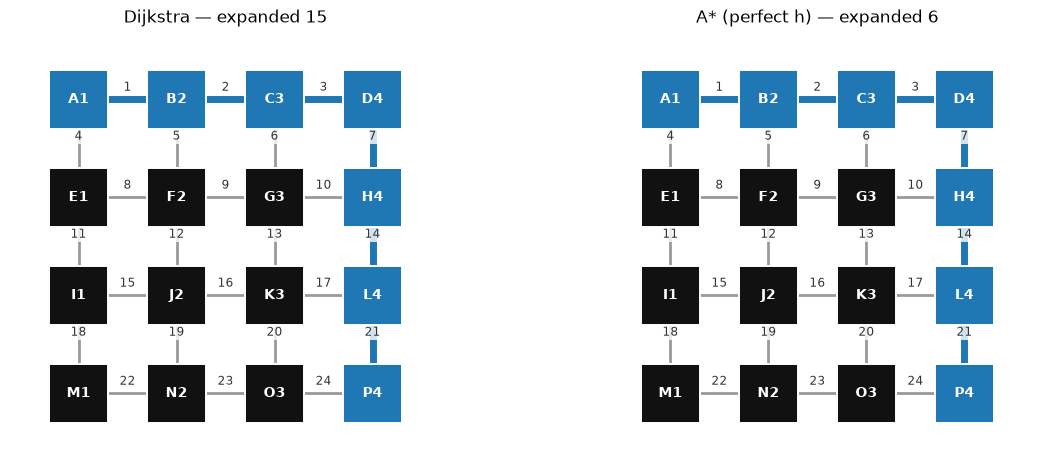

path (both): A1 -> B2 -> C3 -> D4 -> H4 -> L4 -> P4 | cost 48.0
Dijkstra expanded 15 nodes; A* expanded 6


In [7]:
# The original 4x4 weighted graph, plugged into the SAME search engine
# used everywhere else in this lab (via a small adapter).

class EdgeWeightMap:
    """Adapter: an edge-weighted named graph behaves like any other map."""

    def __init__(self, edges):
        self.adj = {}
        for u, v, w in edges:
            self.adj.setdefault(u, {})[v] = w
            self.adj.setdefault(v, {})[u] = w
        self.eight = False

    def neighbors(self, node):
        return self.adj[node].keys()

    def move_cost(self, a, b):
        return self.adj[a][b]

    def passable(self, node):
        return node in self.adj


NAMES_4X4 = [["A1", "B2", "C3", "D4"], ["E1", "F2", "G3", "H4"],
             ["I1", "J2", "K3", "L4"], ["M1", "N2", "O3", "P4"]]
H_WEIGHTS = [[1, 2, 3], [8, 9, 10], [15, 16, 17], [22, 23, 24]]
V_WEIGHTS = [[4, 11, 18], [5, 12, 19], [6, 13, 20], [7, 14, 21]]

EDGES_4X4 = []
for i in range(4):
    for j in range(3):
        EDGES_4X4.append((NAMES_4X4[i][j], NAMES_4X4[i][j + 1], H_WEIGHTS[i][j]))
for j in range(4):
    for i in range(3):
        EDGES_4X4.append((NAMES_4X4[i][j], NAMES_4X4[i + 1][j], V_WEIGHTS[j][i]))

GRAPH_4X4 = EdgeWeightMap(EDGES_4X4)
START_4X4, GOAL_4X4 = "A1", "P4"
POS_4X4 = {NAMES_4X4[i][j]: (j, -i) for i in range(4) for j in range(4)}
MIN_EDGE = min(w for _, _, w in EDGES_4X4)

# graph-aware heuristics for this named graph
def _min_edges_from(goal):
    dist, queue = {goal: 0}, deque([goal])
    while queue:
        u = queue.popleft()
        for v in GRAPH_4X4.neighbors(u):
            if v not in dist:
                dist[v] = dist[u] + 1
                queue.append(v)
    return dist

def _exact_cost_from(goal):
    dist = {n: math.inf for n in GRAPH_4X4.adj}
    dist[goal] = 0
    heap = [(0, goal)]
    while heap:
        d, u = heapq.heappop(heap)
        if d > dist[u]:
            continue
        for v, w in GRAPH_4X4.adj[u].items():
            if d + w < dist[v]:
                dist[v] = d + w
                heapq.heappush(heap, (d + w, v))
    return dist

EDGES_FROM_GOAL = _min_edges_from(GOAL_4X4)
EXACT_FROM_GOAL = _exact_cost_from(GOAL_4X4)

def h_lower_4x4(a, b, grid):        # min-edges-to-goal x cheapest edge
    return EDGES_FROM_GOAL[a] * MIN_EDGE

def h_perfect_4x4(a, b, grid):      # exact remaining cost (teaching heuristic)
    return EXACT_FROM_GOAL[a]


def draw_labeled_graph(result=None, ax=None):
    """Intro-only drawing: dark squares + white labels + edge weights."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7.5, 5.8))
    on_path = set(result.path) if (result and result.path) else set()
    for u, v, w in EDGES_4X4:
        x1, y1 = POS_4X4[u]
        x2, y2 = POS_4X4[v]
        is_path = u in on_path and v in on_path
        ax.plot([x1, x2], [y1, y2], color="#1f77b4" if is_path else "#999999",
                lw=5 if is_path else 2, zorder=1)
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.12, str(w), fontsize=8.5,
                ha="center", va="center", color="#333",
                bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.8))
    for n in GRAPH_4X4.adj:
        x, y = POS_4X4[n]
        fc = "#1f77b4" if n in on_path else ("#2ca02c" if n in (START_4X4, GOAL_4X4) else "#111111")
        ax.add_patch(Rectangle((x - 0.3, y - 0.3), 0.6, 0.6, fc=fc, ec="white", lw=1.4, zorder=2))
        ax.text(x, y, n, color="white", fontsize=10, fontweight="bold",
                ha="center", va="center", zorder=3)
    ax.set_xlim(-0.7, 3.7); ax.set_ylim(-3.7, 0.7)
    ax.set_aspect("equal"); ax.axis("off")

# --- run: Dijkstra (h=0) vs A* (perfect heuristic) --------------------------
dij = dijkstra(GRAPH_4X4, START_4X4, GOAL_4X4)
ast = a_star(GRAPH_4X4, START_4X4, GOAL_4X4, h_perfect_4x4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
draw_labeled_graph(dij, axes[0]); axes[0].set_title(f"Dijkstra — expanded {dij.expanded}")
draw_labeled_graph(ast, axes[1]); axes[1].set_title(f"A* (perfect h) — expanded {ast.expanded}")
plt.show()

print("path (both):", " -> ".join(dij.path), f"| cost {dij.path_cost}")
print(f"Dijkstra expanded {dij.expanded} nodes; A* expanded {ast.expanded}")
assert dij.path_cost == ast.path_cost, "admissible heuristic must keep optimality"

## 3. General-Purpose Grid Representation

A robot's map is usually **not** a hand-drawn 16-node graph. From here on we
use a configurable grid: any `ROWS × COLS`, from 4×4 up to hundreds squared.
Internally every cell is a `(row, col)` tuple — names like `A1`/`P4` were
only labels for the introductory example.

```python
ROWS, COLS = 20, 20
START = (0, 0)
GOAL  = (ROWS - 1, COLS - 1)
```

`GridMap` bundles everything an algorithm needs to know about the world:

- which cells exist (`in_bounds`),
- which cells are obstacles (`passable`),
- which cells are reachable in one move (`neighbors`, 4- or 8-connected),
- how much a move costs (`move_cost` — terrain costs, not distances).

Moving between two adjacent cells costs the **average of their terrain
costs** (× √2 for a diagonal step). On a uniform map all costs are 1, so a
step costs 1 (or √2 diagonal) — but the machinery already supports weighted
terrain for Section 16.

In [8]:
class GridMap:
    """A 2-D occupancy-and-cost grid: the world every later algorithm uses.

    Nodes are (row, col) tuples.
      cost[r, c]  terrain cost of the cell (higher = more expensive to cross)
      blocked     obstacle cells (impossible to enter)
      eight       8-connected movement (diagonals) if True, else 4-connected

    Moving a -> b costs the AVERAGE of the two cells' terrain costs,
    x sqrt(2) for a diagonal step. On uniform maps every step costs 1 (or
    sqrt(2) diagonal) — the same machinery already supports weighted terrain.
    """

    def __init__(self, rows, cols, cost=None, blocked=(), eight=False):
        self.rows, self.cols = int(rows), int(cols)
        self.cost = np.ones((self.rows, self.cols)) if cost is None else np.asarray(cost, float)
        self.blocked = set(blocked)
        self.eight = bool(eight)
        self._minstep = None

    # -- queries -----------------------------------------------------------
    def in_bounds(self, cell):
        r, c = cell
        return 0 <= r < self.rows and 0 <= c < self.cols

    def passable(self, cell):
        return self.in_bounds(cell) and cell not in self.blocked

    def neighbors(self, cell):
        r, c = cell
        cand = [(r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)]
        if self.eight:
            cand += [(r - 1, c - 1), (r - 1, c + 1), (r + 1, c - 1), (r + 1, c + 1)]
        for n in cand:
            if self.passable(n):
                yield n

    def move_cost(self, a, b):
        step = SQRT2 if (a[0] != b[0] and a[1] != b[1]) else 1.0
        return 0.5 * (self.cost[a] + self.cost[b]) * step

    @property
    def min_step_cost(self):
        if self._minstep is None:
            free = (self.cost[~self._mask_blocked()]).min() if self._free_any() else math.inf
            self._minstep = float(free)
        return self._minstep

    def _mask_blocked(self):
        m = np.zeros((self.rows, self.cols), bool)
        if self.blocked:
            rs, cs = zip(*self.blocked)
            m[list(rs), list(cs)] = True
        return m

    def _free_any(self):
        return self.blocked.__len__() < self.rows * self.cols

    # -- mutation ------------------------------------------------------------
    def block(self, cell):
        self.blocked.add(cell)
        self._minstep = None

    def unblock(self, cell):
        self.blocked.discard(cell)
        self._minstep = None

    def is_uniform(self):
        return bool(np.all(self.cost == self.cost.flat[0]))

    def clone(self):
        return GridMap(self.rows, self.cols, self.cost.copy(), set(self.blocked), self.eight)

    def __repr__(self):
        return (f"GridMap({self.rows}x{self.cols}, {len(self.blocked)} blocked, "
                f"{'8' if self.eight else '4'}-connected)")


# --- quick tour ---------------------------------------------------------------
ROWS, COLS = 10, 10
demo_grid = GridMap(ROWS, COLS, blocked={(4, 4), (4, 5), (5, 4)}, eight=True)
START, GOAL = (0, 0), (ROWS - 1, COLS - 1)

print(demo_grid)
print("neighbors of (5,5):", sorted(demo_grid.neighbors((5, 5))))
print("cost (5,5)->(5,6):", demo_grid.move_cost((5, 5), (5, 6)))
print("cost (5,5)->(6,6) diagonal:", round(demo_grid.move_cost((5, 5), (6, 6)), 3))
print("cheapest step cost:", demo_grid.min_step_cost)

GridMap(10x10, 3 blocked, 8-connected)
neighbors of (5,5): [(4, 6), (5, 6), (6, 4), (6, 5), (6, 6)]
cost (5,5)->(5,6): 1.0
cost (5,5)->(6,6) diagonal: 1.414
cheapest step cost: 1.0


In [9]:
# --- ONE visualization routine for every algorithm (consumes SearchState) ----

PALETTE = {
    "start": "#2ca02c", "goal": "#ffd700", "open": "#ff9d2e",
    "closed": "#8c8c8c", "current": "#e63946", "path": "#1f77b4",
    "robot": "#6a3d9a", "open_b": "#7fd4ff", "closed_b": "#3a7ca5",
    "meeting": "#ff00ff", "obstacle": "#262626",
}

def validate_path(grid, path, start=None, goal=None):
    """Mechanically check a returned path: neighbors, passable, cost."""
    if path is None:
        return False, math.inf
    if len(path) < 1 or (start and path[0] != start) or (goal and path[-1] != goal):
        return False, math.inf
    total = 0.0
    for a, b in zip(path, path[1:]):
        if b not in list(grid.neighbors(a)):
            return False, math.inf
        total += grid.move_cost(a, b)
    return True, total

def draw_state(grid, search=None, robot=None, title="", ax=None, show_labels=True):
    """Paint the map; if a search (or SearchState) is given, paint its state."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6.8, 6.8))
    else:
        fig = ax.figure

    state = search
    if search is not None and not isinstance(search, SearchState):
        state = search.snapshot()

    # terrain + obstacles as one RGB image
    lo, hi = float(grid.cost.min()), float(grid.cost.max())
    span = (hi - lo) or 1.0
    val = (grid.cost - lo) / span
    img = plt.cm.YlOrBr(0.15 + 0.55 * val)                 # pale -> amber
    img[grid._mask_blocked()] = (0.15, 0.15, 0.15, 1.0)    # obstacles: dark
    ax.imshow(img, interpolation="nearest", origin="upper", zorder=0)

    handles = []
    def cells(items, color, label, marker="s", size=40, alpha=1.0, edge="none"):
        if not items:
            return
        rs, cs = zip(*items)
        ax.scatter(cs, rs, c=color, marker=marker, s=size, alpha=alpha,
                   edgecolors=edge, linewidths=1.2, zorder=3)
        handles.append(Patch(facecolor=color, label=label))

    if state is not None:
        cells(sorted(state.closed_set), PALETTE["closed"], "closed")
        cells(sorted(state.open_set), PALETTE["open"], "open")
        ex = state.extras
        if "closed_b" in ex:                                # bidirectional
            cells(sorted(ex["closed_b"]), PALETTE["closed_b"], "closed (backward)")
            cells(sorted(ex["open_b"]), PALETTE["open_b"], "open (backward)")
        if ex.get("meeting") is not None:
            mr, mc = ex["meeting"]
            ax.scatter([mc], [mr], c=PALETTE["meeting"], marker="*", s=260,
                       edgecolors="black", linewidths=0.8, zorder=6)
            handles.append(Patch(facecolor=PALETTE["meeting"], label="meeting"))
        if state.current is not None and state.status == "running":
            cr, cc = state.current
            ax.scatter([cc], [cr], facecolors="none", edgecolors=PALETTE["current"],
                       marker="s", s=140, linewidths=2.4, zorder=6)
            handles.append(Patch(facecolor=PALETTE["current"], label="current"))
        if state.path:
            prs = [p[0] for p in state.path]
            pcs = [p[1] for p in state.path]
            ax.plot(pcs, prs, color=PALETTE["path"], lw=3, zorder=4,
                    solid_capstyle="round")
            handles.append(Patch(facecolor=PALETTE["path"], label="path"))

    if robot is not None:
        rr, rc = robot
        ax.scatter([rc], [rr], c=PALETTE["robot"], marker="o", s=180,
                   edgecolors="white", linewidths=1.6, zorder=7)
        handles.append(Patch(facecolor=PALETTE["robot"], label="robot"))

    # grid lines + axes
    ax.set_xticks(np.arange(-0.5, grid.cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.rows, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.25, alpha=0.5)
    stride = max(1, max(grid.rows, grid.cols) // 12)
    ax.set_xticks(np.arange(0, grid.cols, stride))
    ax.set_yticks(np.arange(0, grid.rows, stride))
    ax.set_xlim(-0.5, grid.cols - 0.5)
    ax.set_ylim(grid.rows - 0.5, -0.5)
    ax.tick_params(labelsize=7)

    if not title and state is not None:
        title = f"{state.name} — {state.status}"
        if state.path_cost is not None:
            title += f" · cost {state.path_cost:.2f} · {len(state.path)} cells"
        title += f" · expanded {state.expanded}"
    ax.set_title(title, fontsize=11)
    return fig, ax


def draw_start_goal(ax, start, goal):
    """Overlay explicit START / GOAL markers (used by all demo figures)."""
    ax.scatter([start[1]], [start[0]], c=PALETTE["start"], marker="o", s=170,
               edgecolors="black", linewidths=1.2, zorder=7, label="start")
    ax.scatter([goal[1]], [goal[0]], c=PALETTE["goal"], marker="*", s=300,
               edgecolors="black", linewidths=1.0, zorder=7, label="goal")
    ax.legend(loc="upper right", fontsize=8, framealpha=0.9)

print("visualization ready — every algorithm feeds draw_state() the same state model")

visualization ready — every algorithm feeds draw_state() the same state model


## 4. Map Generation

Reusable, seeded generators keep experiments reproducible (`SEED = 42` gives
the same map every time):

```python
create_empty_grid(rows, cols)
create_random_obstacles(rows, cols, density, seed)
create_random_cost_map(rows, cols, seed)      # weighted terrain
create_maze(rows, cols, seed)                 # recursive-backtracker maze
```

Random maps are checked so start and goal are actually connected (otherwise
you get an accidental "impossible route" — Section 15 covers those on
purpose). Presets: **Empty · Random Obstacles · Dense Obstacles · Maze ·
Weighted Terrain**.

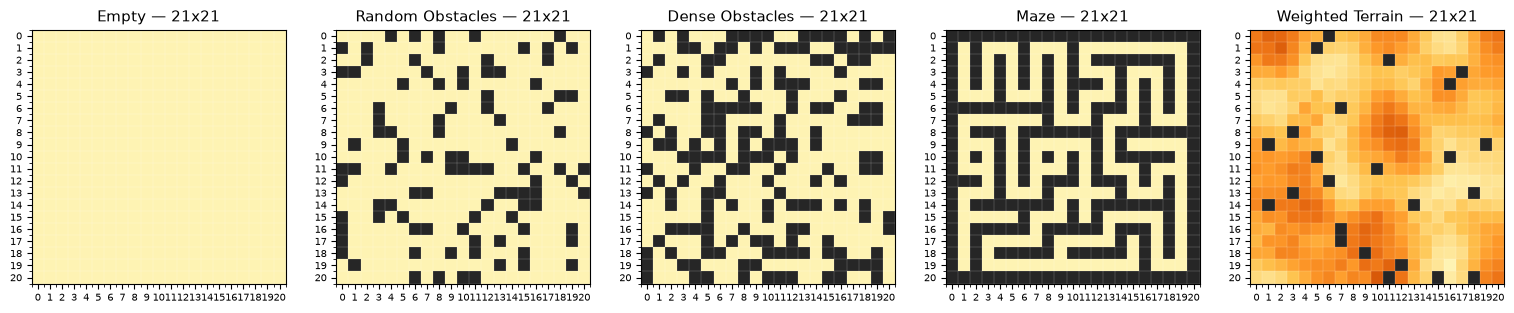

generators ready: ['Empty', 'Random Obstacles', 'Dense Obstacles', 'Maze', 'Weighted Terrain']


In [10]:
# --- map generators (all seeded => reproducible experiments) -----------------

def create_empty_grid(rows, cols, eight=False):
    return GridMap(rows, cols, eight=eight)

def _reachable(grid, start, goal):
    seen, queue = {start}, deque([start])
    while queue:
        u = queue.popleft()
        if u == goal:
            return True
        for v in grid.neighbors(u):
            if v not in seen:
                seen.add(v)
                queue.append(v)
    return goal in seen

def create_random_obstacles(rows, cols, density=0.25, seed=0, eight=False,
                            ensure_path=True, start=None, goal=None):
    start = start or (0, 0)
    goal = goal or (rows - 1, cols - 1)
    for attempt in range(60):
        rng = np.random.default_rng(seed * 1000 + attempt)
        mask = rng.random((rows, cols)) < density
        blocked = {(int(r), int(c)) for r, c in np.argwhere(mask)}
        blocked -= {start, goal}
        m = GridMap(rows, cols, blocked=blocked, eight=eight)
        if not ensure_path or _reachable(m, start, goal):
            return m
    return create_empty_grid(rows, cols, eight=eight)   # give up safely

def _smooth(a, passes=2):
    out = a.astype(float)
    for _ in range(passes):
        acc, cnt = out.copy(), np.ones_like(out)
        acc[1:, :] += out[:-1, :]; cnt[1:, :] += 1
        acc[:-1, :] += out[1:, :]; cnt[:-1, :] += 1
        acc[:, 1:] += out[:, :-1]; cnt[:, 1:] += 1
        acc[:, :-1] += out[:, 1:]; cnt[:, :-1] += 1
        out = acc / cnt
    return out

def create_random_cost_map(rows, cols, seed=0, eight=False, max_cost=8.0,
                           blocked_density=0.05):
    """Weighted terrain: smooth random hills of cost 1..max_cost."""
    rng = np.random.default_rng(seed)
    terrain = 1.0 + _smooth(rng.random((rows, cols)), passes=3) * (max_cost - 1.0)
    m = create_random_obstacles(rows, cols, blocked_density, seed + 777, eight)
    m.cost = terrain
    m._minstep = None
    return m

def create_maze(rows, cols, seed=0, braid=0.15, eight=False):
    """Recursive-backtracker maze; `braid` opens a few walls so there are
    alternate routes (perfect mazes have exactly one path)."""
    rows = max(3, rows if rows % 2 else rows - 1)
    cols = max(3, cols if cols % 2 else cols - 1)
    rng = random.Random(seed)
    blocked = {(r, c) for r in range(rows) for c in range(cols)}
    start_cell = (1, 1)
    blocked.discard(start_cell)
    stack, visited = [start_cell], {start_cell}
    while stack:
        r, c = stack[-1]
        nbrs = [(r + dr, c + dc) for dr, dc in ((-2, 0), (2, 0), (0, -2), (0, 2))
                if 1 <= r + dr < rows - 1 and 1 <= c + dc < cols - 1
                and (r + dr, c + dc) not in visited]
        if nbrs:
            nr, nc = rng.choice(nbrs)
            blocked.discard((nr, nc))
            blocked.discard(((r + nr) // 2, (c + nc) // 2))
            visited.add((nr, nc))
            stack.append((nr, nc))
        else:
            stack.pop()
    # braid: knock a wall next to some dead ends
    for (r, c) in list(visited):
        open_n = [(r + dr, c + dc) for dr, dc in ((-1, 0), (1, 0), (0, -1), (0, 1))
                  if (r + dr, c + dc) not in blocked]
        if len(open_n) == 1 and rng.random() < braid:
            walls = [(r + dr, c + dc) for dr, dc in ((-1, 0), (1, 0), (0, -1), (0, 1))
                     if 0 < r + dr < rows - 1 and 0 < c + dc < cols - 1
                     and (r + dr, c + dc) in blocked]
            if walls:
                blocked.discard(rng.choice(walls))
    return GridMap(rows, cols, blocked=blocked, eight=eight)

PRESETS = {
    "Empty": lambda rows, cols, seed, eight: create_empty_grid(rows, cols, eight),
    "Random Obstacles": lambda rows, cols, seed, eight:
        create_random_obstacles(rows, cols, 0.25, seed, eight),
    "Dense Obstacles": lambda rows, cols, seed, eight:
        create_random_obstacles(rows, cols, 0.45, seed, eight),
    "Maze": lambda rows, cols, seed, eight: create_maze(rows, cols, seed, eight=eight),
    "Weighted Terrain": lambda rows, cols, seed, eight:
        create_random_cost_map(rows, cols, seed, eight),
}

# --- the preset gallery -------------------------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(19, 3.8))
for ax, (name, make) in zip(axes, PRESETS.items()):
    m = make(21, 21, seed=42, eight=False)
    draw_state(m, title=f"{name} — 21x21", ax=ax)
plt.show()
print("generators ready:", list(PRESETS))

## 5. BFS — Breadth-First Search

BFS explores the grid **layer by layer**: all cells 1 step away, then 2 steps
away, then 3… It uses a FIFO queue, so nodes leave in the order they entered.

- BFS finds the path with the **fewest edges**.
- On a uniform-cost grid, fewest edges = cheapest, so BFS is optimal *there*.
- On a **weighted** grid, fewest edges ≠ cheapest: a 3-edge path crossing
  expensive terrain can cost more than a 6-edge path. BFS has no notion of
  cost — watch it return a shorter-but-more-expensive path in the demo below.

Fun fact used later: BFS is also how we check reachability when generating
maps.

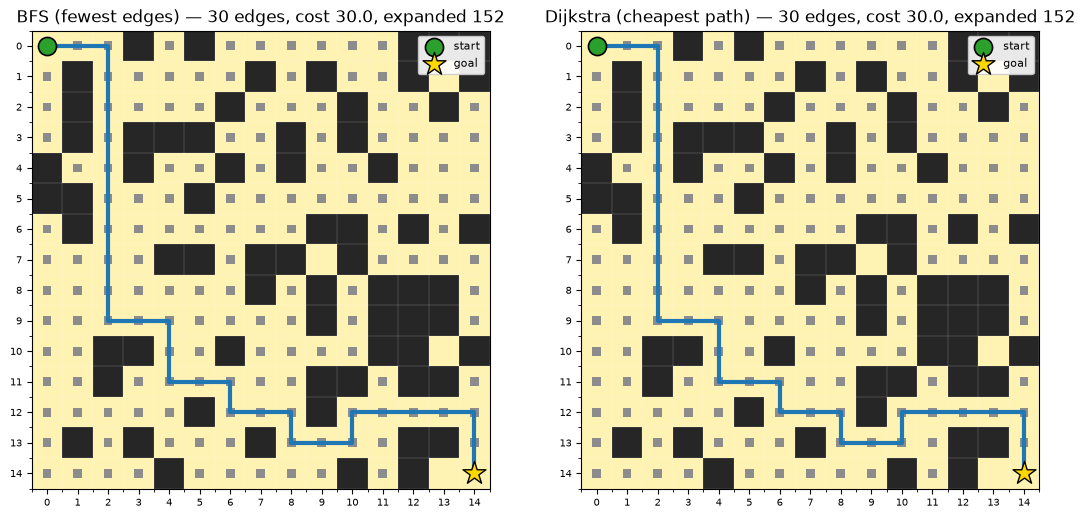

BFS:      30 edges, cost 30.00  (valid: True)
Dijkstra: 30 edges, cost 30.00

On this uniform map both are optimal — BFS fewest edges == cheapest here.
On weighted terrain (Section 17) the two will DISAGREE.


In [11]:
# BFS on a uniform grid: fewest EDGES. Compare with Dijkstra's cheapest path.
grid = create_random_obstacles(15, 15, 0.25, seed=3)
START, GOAL = (0, 0), (14, 14)

res_bfs = bfs(grid, START, GOAL)
res_dij = dijkstra(grid, START, GOAL)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.2))
for ax, res, note in ((axes[0], res_bfs, "fewest edges"),
                      (axes[1], res_dij, "cheapest path")):
    draw_state(grid, res, ax=ax)
    draw_start_goal(ax, START, GOAL)
    ax.set_title(f"{res.name} ({note}) — {len(res.path)-1} edges, "
                 f"cost {res.path_cost:.1f}, expanded {res.expanded}")
plt.show()

ok, cost = validate_path(grid, res_bfs.path, START, GOAL)
print(f"BFS:      {len(res_bfs.path)-1} edges, cost {res_bfs.path_cost:.2f}  (valid: {ok})")
print(f"Dijkstra: {len(res_dij.path)-1} edges, cost {res_dij.path_cost:.2f}")
print("\nOn this uniform map both are optimal — BFS fewest edges == cheapest here.")
print("On weighted terrain (Section 17) the two will DISAGREE.")

## 6. DFS — Depth-First Search

DFS dives **as deep as possible** before backtracking, using a LIFO stack.
It is included as a *traversal* comparison:

- it finds *a* path, rarely the short one;
- it is **not** a shortest-path algorithm for navigation;
- its expansion order is the opposite of BFS's tidy rings — one long tendril.

Switch the algorithm dropdown in the explorer (Section 15) to DFS and step
through it — the difference is immediately visible.

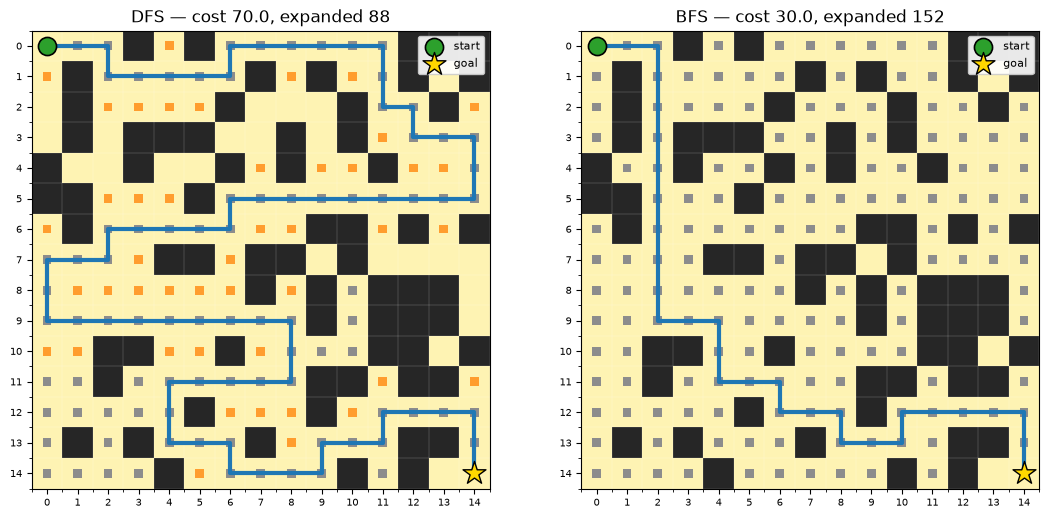

DFS found a path of 70 edges — BFS needs only 30. DFS explores deeply, not broadly.


In [12]:
# DFS: a long tendril instead of BFS's tidy rings.
grid = create_random_obstacles(15, 15, 0.25, seed=3)
START, GOAL = (0, 0), (14, 14)

res_dfs = dfs(grid, START, GOAL)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.2))
draw_state(grid, res_dfs, ax=axes[0]); draw_start_goal(axes[0], START, GOAL)
axes[0].set_title(f"DFS — cost {res_dfs.path_cost:.1f}, expanded {res_dfs.expanded}")
res_bfs = bfs(grid, START, GOAL)
draw_state(grid, res_bfs, ax=axes[1]); draw_start_goal(axes[1], START, GOAL)
axes[1].set_title(f"BFS — cost {res_bfs.path_cost:.1f}, expanded {res_bfs.expanded}")
plt.show()

print(f"DFS found a path of {len(res_dfs.path)-1} edges — BFS needs only "
      f"{len(res_bfs.path)-1}. DFS explores deeply, not broadly.")

## 7. Dijkstra's Algorithm

Dijkstra expands, always, the frontier node with the smallest cost-so-far:

$$f(n) = g(n)$$

```text
g(n)        cost already travelled from START
came_from   how we got here (for path rebuilding)
OPEN        frontier: discovered but not yet expanded
CLOSED      expanded, finished
expanded    how many nodes we paid work for
```

It is **uninformed**: it has no idea where the goal is until it stumbles
into it, so it floods a near-circle around the start. Optimal on any graph
with non-negative edge costs — and, as we'll see, exactly what A* becomes
when h(n) = 0.

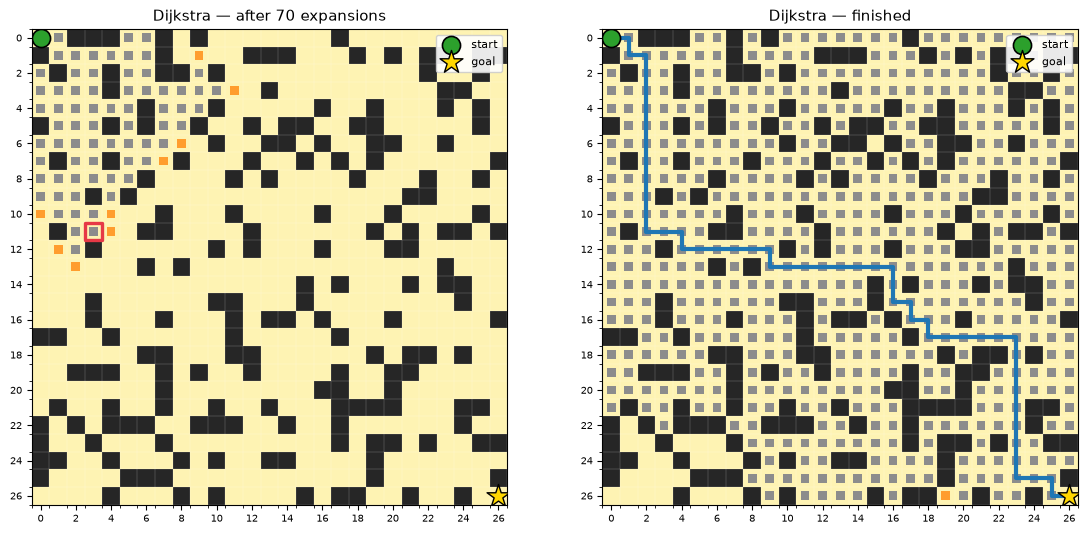

finished: status=goal, cost=52.00, path cells=53, expanded=514, peak frontier=21
Notice the near-circular explored region — Dijkstra knows nothing about WHERE the goal is; it just grows the cheap frontier in every direction.


In [13]:
# Dijkstra on a bigger map: watch the uniform flood around the start.
grid = create_random_obstacles(27, 27, 0.25, seed=11)
START, GOAL = (0, 0), (26, 26)

partial = DijkstraSearch(grid, START, GOAL)
for _ in range(70):
    partial.step()

final = dijkstra(grid, START, GOAL)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.4))
for ax, res, cap in ((axes[0], partial, "after 70 expansions"),
                     (axes[1], final, "finished")):
    draw_state(grid, res, ax=ax, title=f"Dijkstra — {cap}")
    draw_start_goal(ax, START, GOAL)
plt.show()

print(f"finished: status={final.status}, cost={final.path_cost:.2f}, "
      f"path cells={len(final.path)}, expanded={final.expanded}, "
      f"peak frontier={final.peak_open}")
print("Notice the near-circular explored region — Dijkstra knows nothing about"
      " WHERE the goal is; it just grows the cheap frontier in every direction.")

## 8. Greedy Best-First Search

Greedy Best-First expands the frontier node that *looks* closest to the
goal, ignoring the cost already paid:

$$f(n) = h(n)$$

The three attitudes in one place:

```text
Greedy:    "What looks closest to the goal right now?"
Dijkstra:  "What is cheapest so far?"
A*:        "What is cheapest overall, considering both?"
```

Greedy is fast and often finds a reasonable path, but it can be **lured into
dead ends and expensive detours** — h(n) alone can trick it. On the demo
below, compare its path cost with Dijkstra's.

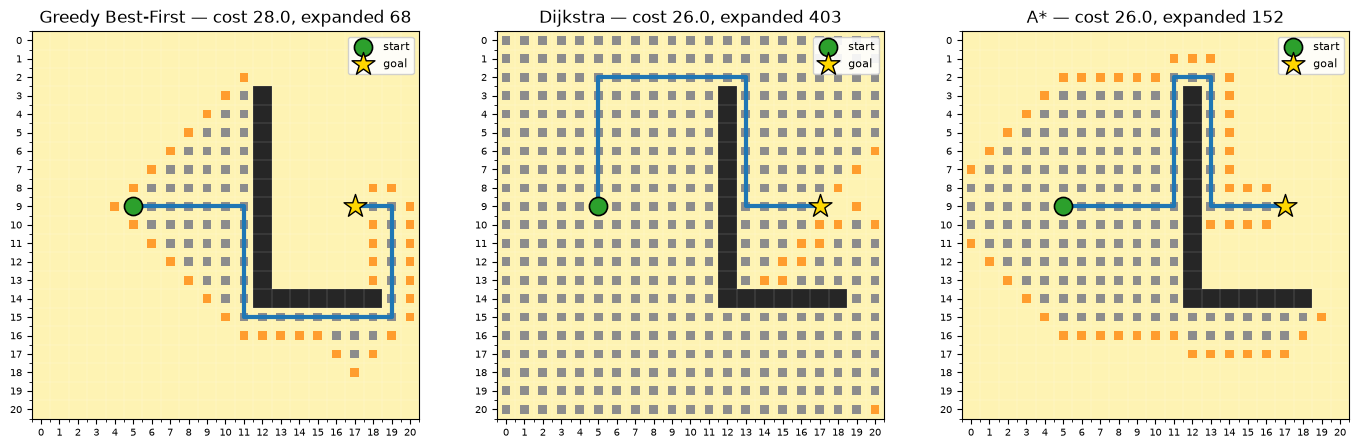

algorithm               cost  edges  expanded
Greedy Best-First      28.00     28        68
Dijkstra               26.00     26       403
A*                     26.00     26       152

Greedy expanded the least — and paid the most. h(n) alone is a gambler; g(n)+h(n) is a strategist. (On this uniform map manhattan is admissible, so A* matches Dijkstra's optimal cost.)


In [14]:
# Greedy Best-First on a map with a U-shaped trap: it beelines into the trap.
grid = create_empty_grid(21, 21)
for r in range(3, 15):           # vertical wall with an opening at the bottom
    grid.block((r, 12))
for c in range(12, 19):          # ...extended into a hook: the trap
    grid.block((14, c))
START, GOAL = (9, 5), (9, 17)

results = {
    "Greedy Best-First": greedy_best_first(grid, START, GOAL, h_manhattan),
    "Dijkstra": dijkstra(grid, START, GOAL),
    "A*": a_star(grid, START, GOAL, h_manhattan),
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5.6))
for ax, (name, res) in zip(axes, results.items()):
    draw_state(grid, res, ax=ax)
    draw_start_goal(ax, START, GOAL)
    ax.set_title(f"{name} — cost {res.path_cost:.1f}, expanded {res.expanded}")
plt.show()

print(f"{'algorithm':<20}{'cost':>8}{'edges':>7}{'expanded':>10}")
for name, res in results.items():
    print(f"{name:<20}{res.path_cost:>8.2f}{len(res.path)-1:>7}{res.expanded:>10}")
print("\nGreedy expanded the least — and paid the most. h(n) alone is a gambler;"
      " g(n)+h(n) is a strategist. (On this uniform map manhattan is admissible,"
      " so A* matches Dijkstra's optimal cost.)")

## 9. A* — Adding a Sense of Direction

A* combines both terms:

$$f(n) = g(n) + h(n)$$

- `g(n)`: cost already travelled (what Dijkstra uses),
- `h(n)`: estimated remaining cost (what Greedy uses),
- `f(n)`: estimated total cost of a path through n.

If h never overestimates the true remaining cost (an **admissible**
heuristic), A* is guaranteed to find a shortest path — typically while
expanding far fewer nodes than Dijkstra, because nodes pointing away from
the goal get inflated f-scores and wait.

Two exact identities this lab demonstrates live:

```text
A* with h(n) = 0        =  Dijkstra
Greedy with g ignored   =  A* missing half its formula
```

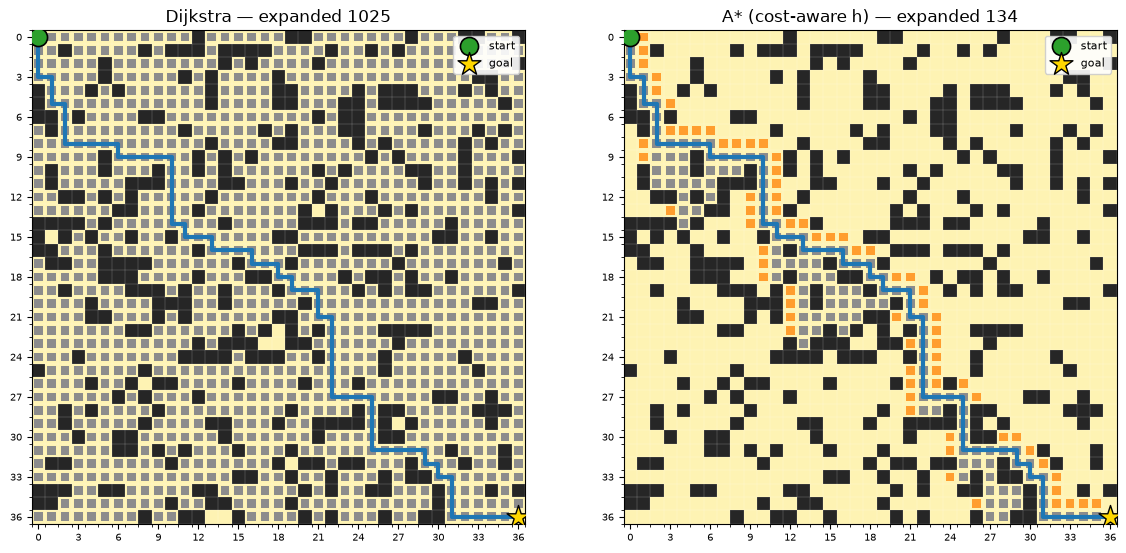

cost: Dijkstra 72.00 | A* 72.00 (must be equal: admissible heuristic)
expanded: Dijkstra 1025 | A* 134

Identity check: A* with h=0 expanded 1025 nodes — identical to Dijkstra. Same algorithm, zero knowledge.


In [15]:
# Dijkstra vs A* on the same map — and the h=0 identity check.
grid = create_random_obstacles(37, 37, 0.25, seed=21)
START, GOAL = (0, 0), (36, 36)

res_dij = dijkstra(grid, START, GOAL)
res_ast = a_star(grid, START, GOAL, h_cost_aware)
res_a0 = a_star(grid, START, GOAL, h_zero)        # A* with h = 0 ...

fig, axes = plt.subplots(1, 2, figsize=(14, 6.6))
draw_state(grid, res_dij, ax=axes[0]); draw_start_goal(axes[0], START, GOAL)
draw_state(grid, res_ast, ax=axes[1]); draw_start_goal(axes[1], START, GOAL)
axes[0].set_title(f"Dijkstra — expanded {res_dij.expanded}")
axes[1].set_title(f"A* (cost-aware h) — expanded {res_ast.expanded}")
plt.show()

print(f"cost: Dijkstra {res_dij.path_cost:.2f} | A* {res_ast.path_cost:.2f} "
      f"(must be equal: admissible heuristic)")
print(f"expanded: Dijkstra {res_dij.expanded} | A* {res_ast.expanded}")
assert math.isclose(res_dij.path_cost, res_ast.path_cost, rel_tol=1e-9)
assert res_dij.expanded == res_a0.expanded, "A* with h=0 must expand EXACTLY like Dijkstra"
print(f"\nIdentity check: A* with h=0 expanded {res_a0.expanded} nodes — "
      f"identical to Dijkstra. Same algorithm, zero knowledge.")

## 10. Heuristics — and Why Grids Don't Make Them Automatic

A grid layout is **geometry**; traversal cost is **cost**. They are not the
same thing:

```text
Grid geometry  ≠  Traversal cost
```

Manhattan or Euclidean distance assume "one grid step costs at least 1" —
true on a uniform cost-1 map, **false in general** on weighted terrain. The
lab ships four heuristics:

| heuristic | formula | admissible when… |
|---|---|---|
| `zero` | h(n) = 0 | always (turns A* into Dijkstra) |
| `manhattan` | \|Δrow\| + \|Δcol\| | uniform cost-1 grids |
| `euclidean` | straight-line distance | uniform grids (also 8-connected) |
| `cost-aware` | octile/manhattan × cheapest cell cost | **any weighted grid in this lab** |

`cost-aware` is built from the map's own cost structure: any path must take
at least *octile-count* steps, each costing at least the cheapest traversable
cell — so the product can never overestimate. The demo also shows an
**overestimating** heuristic in action: it explores fewer nodes but can
return a suboptimal path. Heuristic strength is a trade-off, not a free
lunch.

In [16]:
# Four heuristics on WEIGHTED terrain — admissibility made visible.
grid = create_random_cost_map(31, 31, seed=9)
START, GOAL = (0, 0), (30, 30)

rows = []
for hname, hfun in HEURISTICS.items():
    res = a_star(grid, START, GOAL, hfun)
    ok, _ = validate_path(grid, res.path, START, GOAL)
    rows.append({"heuristic": hname, "path cost": round(res.path_cost, 2),
                 "path cells": len(res.path), "expanded": res.expanded,
                 "valid path": ok})

ref = dijkstra(grid, START, GOAL)                  # ground truth (optimal)
df = pd.DataFrame(rows)
display(df)
print(f"Dijkstra optimum: cost {ref.path_cost:.2f}, expanded {ref.expanded}")

admissible = df[df["path cost"].round(6) <= round(ref.path_cost, 6) + 1e-6]["heuristic"].tolist()
print("heuristics that stayed optimal here:", admissible)
assert math.isclose(a_star(grid, START, GOAL, h_cost_aware).path_cost,
                    ref.path_cost, rel_tol=1e-9)
print("\n'cost-aware' is admissible BY CONSTRUCTION on any weighted map, so it always"
      " matches Dijkstra's cost. 'manhattan'/'euclidean' ignore terrain costs — they"
      " may overestimate the remaining cost and can return a SUBOPTIMAL path"
      " (they explore fewer nodes while doing it — that is the trade-off).")

,heuristic,path cost,path cells,expanded,valid path
0,zero,243.91,61,911,True
1,manhattan,243.91,61,911,True
2,euclidean,243.91,61,911,True
3,cost-aware,243.91,61,909,True


Dijkstra optimum: cost 243.91, expanded 911
heuristics that stayed optimal here: ['zero', 'manhattan', 'euclidean', 'cost-aware']

'cost-aware' is admissible BY CONSTRUCTION on any weighted map, so it always matches Dijkstra's cost. 'manhattan'/'euclidean' ignore terrain costs — they may overestimate the remaining cost and can return a SUBOPTIMAL path (they explore fewer nodes while doing it — that is the trade-off).


## 11. Bidirectional Dijkstra

Instead of one search from START, run **two** — one from START, one from
GOAL — and let them meet in the middle:

```text
forward:   S → → → → ● ← ← ← ← G   :backward
              meet somewhere here
```

Each side only has to dig *half as deep*, so the explored area can shrink
from one big disc to two smaller ones. We stop when
`min-g(forward open) + min-g(backward open) ≥ best meeting cost found` — a
safe stopping rule that guarantees optimality (the A* variant adds a second
safe rule based on the f-values; both are explained in the code).

**No blanket claims.** Whether bidirectional search helps depends on map
structure and obstacle layout. Below we *measure* expanded nodes against
plain Dijkstra on the same map.

In [17]:
class _Side:
    """One frontier of a bidirectional search (forward or backward)."""

    def __init__(self, origin, target, use_heuristic, heuristic, grid):
        self.origin, self.target = origin, target
        self.grid = grid
        self.use_heuristic = use_heuristic
        self.heuristic = heuristic
        self.g = {origin: 0.0}
        self.came = {}
        self.open_set = {origin}
        self.closed = set()
        self.heap = []          # ordered by f = g (+ h)
        self.gheap = []         # ordered by g only (for the stopping rule)
        self.push(origin)

    def h(self, node):
        return self.heuristic(node, self.target, self.grid) if self.use_heuristic else 0.0

    def push(self, node):
        heapq.heappush(self.heap, (self.g[node] + self.h(node), node))
        heapq.heappush(self.gheap, (self.g[node], node))

    def top_key(self):
        while self.heap:
            f, n = self.heap[0]
            if n in self.open_set:
                return f
            heapq.heappop(self.heap)
        return math.inf

    def top_g(self):
        while self.gheap:
            g, n = self.gheap[0]
            if n in self.open_set:
                return g
            heapq.heappop(self.gheap)
        return math.inf

    def pop(self):
        while self.heap:
            _, node = heapq.heappop(self.heap)
            if node in self.open_set:
                self.open_set.discard(node)
                return node
        return None


class BidirectionalSearch:
    """Two searches (START->GOAL and GOAL->START) that meet in the middle.

    mode="dijkstra": each side orders its frontier by g.
    mode="astar":    each side orders by f = g + h toward its own target.

    Stopping rule (safe for optimality): the search ends when
        min-g over forward open + min-g over backward open  >=  best meeting
    Any undiscovered better path would have to cross both frontiers, and each
    crossing already costs at least those minima.
    """

    def __init__(self, grid, start, goal, mode="dijkstra", heuristic=None):
        self.grid = grid
        self.start, self.goal = start, goal
        self.mode = mode
        self.name = f"Bidirectional {'A*' if mode == 'astar' else 'Dijkstra'}"
        self.heuristic = heuristic or h_cost_aware
        self.reset()

    def reset(self):
        self.fwd = _Side(self.start, self.goal, self.mode == "astar", self.heuristic, self.grid)
        self.bwd = _Side(self.goal, self.start, self.mode == "astar", self.heuristic, self.grid)
        self.best_meet, self.best_cost = None, math.inf
        self.expanded = 0
        self.elapsed = 0.0
        self._turn = 0
        self.status = "running"
        self.path, self.path_cost = None, None
        self.current, self.current_b = None, None

    def _try_meet(self, node, other: _Side, cost_here):
        cost = cost_here + other.g.get(node, math.inf)
        if cost < self.best_cost:
            self.best_cost, self.best_meet = cost, node

    def _expand_side(self, side: _Side, other: _Side):
        node = side.pop()
        if node is None:
            return
        side.closed.add(node)
        self.expanded += 1
        if side is self.fwd:
            self.current = node
        else:
            self.current_b = node
        self._try_meet(node, other, side.g[node])
        for nb in self.grid.neighbors(node):
            if nb in side.closed:
                continue
            tentative = side.g[node] + self.grid.move_cost(node, nb)
            if tentative < side.g.get(nb, math.inf):
                side.g[nb] = tentative
                side.came[nb] = node
                side.open_set.add(nb)
                side.push(nb)
            self._try_meet(nb, other, side.g.get(nb, math.inf))

    def step(self):
        if self.status != "running":
            return False
        t0 = time.perf_counter()
        if not self.fwd.open_set and not self.bwd.open_set:
            self.status = "no path" if self.best_meet is None else "goal"
            if self.best_meet is not None:
                self._finish()
            return False
        # stopping rules (both safe for optimality with consistent heuristics):
        #   (a) g-cut:  min-g(fwd open) + min-g(bwd open) >= best meeting
        #   (b) f-cut:  min-f(fwd open) + min-f(bwd open) >= 2 x best meeting
        # (a) is tight for Dijkstra ordering; (b) fires early when heuristics
        # steer both sides toward each other (A* ordering).
        if self.best_meet is not None and (
            self.fwd.top_g() + self.bwd.top_g() >= self.best_cost - 1e-9
            or self.fwd.top_key() + self.bwd.top_key() >= 2 * self.best_cost - 1e-9
        ):
            self.status = "goal"
            self._finish()
            return False
        # expand strictly alternating sides (balanced growth); stopping is
        # still decided by the conservative g-based rule above
        if self.fwd.open_set and (not self.bwd.open_set or self._turn == 0):
            self._expand_side(self.fwd, self.bwd)
            self._turn = 1
        else:
            self._expand_side(self.bwd, self.fwd)
            self._turn = 0
        self.elapsed += time.perf_counter() - t0
        return True

    def _finish(self):
        m = self.best_meet
        head = [m]
        while head[-1] != self.fwd.origin:
            head.append(self.fwd.came[head[-1]])
        tail = [m]
        while tail[-1] != self.bwd.origin:
            tail.append(self.bwd.came[tail[-1]])
        self.path = head[::-1] + tail[1:]
        self.path_cost = self.best_cost

    def run(self):
        while self.step():
            pass
        return self

    def snapshot(self):
        return SearchState(
            name=self.name, status=self.status, current=self.current,
            open_set=set(self.fwd.open_set), closed_set=set(self.fwd.closed),
            g=self.fwd.g, path=self.path, path_cost=self.path_cost,
            expanded=self.expanded,
            extras={"open_b": set(self.bwd.open_set), "closed_b": set(self.bwd.closed),
                    "meeting": self.best_meet})


def bidirectional_dijkstra(grid, start, goal):
    return BidirectionalSearch(grid, start, goal, "dijkstra").run()

def bidirectional_a_star(grid, start, goal, heuristic=None):
    return BidirectionalSearch(grid, start, goal, "astar", heuristic).run()

print("bidirectional search ready")

bidirectional search ready


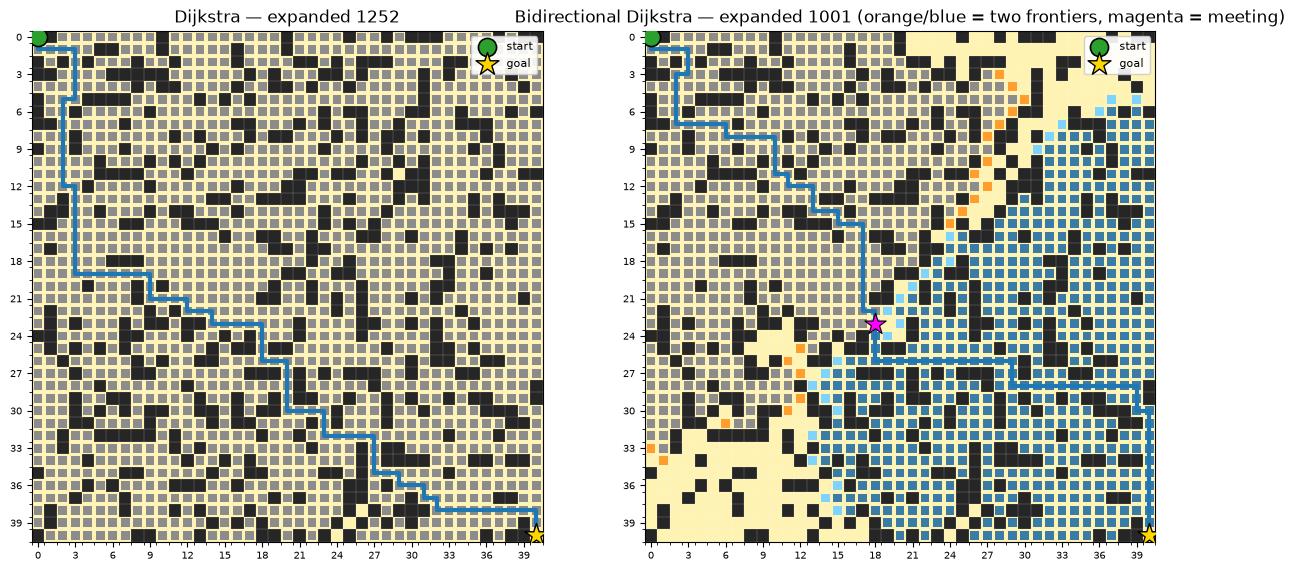

cost: 82.00 vs 82.00 (equal: safe stopping rule)
expanded: 1252 vs 1001 — measured, not asserted.
The saving depends on map shape and obstacle layout; it is not guaranteed.


In [18]:
# Bidirectional Dijkstra: two half-depth digs instead of one full one.
grid = create_random_obstacles(41, 41, 0.25, seed=13)
START, GOAL = (0, 0), (40, 40)

res_one = dijkstra(grid, START, GOAL)
res_bi = bidirectional_dijkstra(grid, START, GOAL)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.8))
draw_state(grid, res_one, ax=axes[0]); draw_start_goal(axes[0], START, GOAL)
draw_state(grid, res_bi, ax=axes[1]); draw_start_goal(axes[1], START, GOAL)
axes[0].set_title(f"Dijkstra — expanded {res_one.expanded}")
axes[1].set_title(f"Bidirectional Dijkstra — expanded {res_bi.expanded} "
                 f"(orange/blue = two frontiers, magenta = meeting)")
plt.show()

print(f"cost: {res_one.path_cost:.2f} vs {res_bi.path_cost:.2f} (equal: safe stopping rule)")
assert math.isclose(res_one.path_cost, res_bi.path_cost, rel_tol=1e-9)
print(f"expanded: {res_one.expanded} vs {res_bi.expanded} — measured, not asserted."
      "\nThe saving depends on map shape and obstacle layout; it is not guaranteed.")

## 12. Bidirectional A*

Same meeting-in-the-middle idea, but each side orders its frontier by
`f = g + h` with its own heuristic (forward estimates distance to GOAL,
backward estimates distance to START). Expansion is directional; termination
still uses the conservative g-based rule, so optimality is preserved.

Again we measure rather than assert: the table below compares Dijkstra,
A*, bidirectional Dijkstra and bidirectional A* on identical maps.

In [19]:
# All four point-to-point strategies, several maps, one honest table.
rows = []
for seed in (13, 99, 2024):
    grid = create_random_obstacles(41, 41, 0.25, seed=seed)
    START, GOAL = (0, 0), (40, 40)
    for name, res in [
        ("Dijkstra", dijkstra(grid, START, GOAL)),
        ("A*", a_star(grid, START, GOAL, h_cost_aware)),
        ("Bidirectional Dijkstra", bidirectional_dijkstra(grid, START, GOAL)),
        ("Bidirectional A*", bidirectional_a_star(grid, START, GOAL, h_cost_aware)),
    ]:
        rows.append({"seed": seed, "algorithm": name,
                     "cost": round(res.path_cost, 2),
                     "expanded": res.expanded,
                     "runtime (ms)": round(res.elapsed * 1000, 1)})

df = pd.DataFrame(rows)
display(df)

opt = df.groupby("seed")["cost"].transform("min")
assert (df["cost"] - opt).abs().max() < 1e-6, "all variants must find optimal cost"
print("All four algorithms agree on the optimal cost for every map — the difference"
      " is purely HOW MUCH of the grid they had to touch to prove it.")

,seed,algorithm,cost,expanded,runtime (ms)
0,13,Dijkstra,82.0,1252,4.2
1,13,A*,82.0,222,1.4
2,13,Bidirectional Dijkstra,82.0,1001,4.7
3,13,Bidirectional A*,82.0,1035,6.0
4,99,Dijkstra,80.0,1263,4.2
5,99,A*,80.0,162,0.9
6,99,Bidirectional Dijkstra,80.0,1037,4.9
7,99,Bidirectional A*,80.0,344,2.1
8,2024,Dijkstra,80.0,1223,4.1
9,2024,A*,80.0,160,0.9


All four algorithms agree on the optimal cost for every map — the difference is purely HOW MUCH of the grid they had to touch to prove it.


## 13. Jump Point Search (JPS)

JPS is an **optimization of A* for uniform-cost grids** — every step costs
the same, obstacles are the only structure. Its trick: while scanning in one
direction, entire straight runs contain nothing interesting, so it "jumps"
over them and only creates search nodes at **jump points** (where the
direction must change or a forced neighbor appears).

Distinguish the two problem classes:

```text
General weighted graph   →  Dijkstra / A* territory
Uniform-cost grid        →  JPS territory
```

Do **not** apply JPS to arbitrary weighted terrain — its pruning rules
assume uniform steps. Below, on a uniform obstacle map, A* and JPS find
paths of identical cost while expanding very different numbers of nodes.

In [20]:
class JPSSearch:
    """Jump Point Search — A* optimized for UNIFORM-COST 8-connected grids.

    Instead of expanding every cell, JPS scans straight ahead in a direction
    and 'jumps' to the next interesting spot (a jump point):
      - the goal, or
      - a cell with a FORCED NEIGHBOR (a wall made a diagonal detour necessary),
      - or, for diagonal scans, a cell whose straight sub-scan finds a jump.
    Everything skipped in between is provably redundant on uniform grids.

    IMPORTANT: JPS's pruning assumes every step costs the same. Do NOT use it
    on weighted terrain — that's A*/Dijkstra territory.
    """

    name = "JPS"
    uses_heuristic = True

    _DIRS = [(-1, 0), (1, 0), (0, -1), (0, 1),
             (-1, -1), (-1, 1), (1, -1), (1, 1)]

    def __init__(self, grid, start, goal, heuristic=None):
        if not grid.eight:
            raise ValueError("JPS needs an 8-connected grid")
        if not grid.is_uniform():
            raise ValueError("JPS assumes uniform step costs (weighted maps not supported)")
        self.grid, self.start, self.goal = grid, start, goal
        self.reset()

    def reset(self):
        self.g = {self.start: 0.0}
        self.came = {}
        self.open_set = {self.start}
        self.closed = set()
        self.current = None
        self.expanded = 0
        self.scanned = 0
        self.status = "running"
        self.path, self.path_cost = None, None
        self._heap = []
        self._push(self.start)

    def _h(self, node):
        return h_octile(node, self.goal, self.grid)

    def _push(self, node):
        self.open_set.add(node)
        heapq.heappush(self._heap, (self.g[node] + self._h(node), node))

    def _forced(self, s, d):
        """Directions at s made unavoidable by an adjacent wall (classic rules)."""
        r, c = s
        dr, dc = d
        forced = []
        if dr == 0:                                   # horizontal scan
            if not self.grid.passable((r + 1, c)) and self.grid.passable((r + 1, c + dc)):
                forced.append((1, dc))
            if not self.grid.passable((r - 1, c)) and self.grid.passable((r - 1, c + dc)):
                forced.append((-1, dc))
        else:                                          # vertical scan
            if not self.grid.passable((r, c + 1)) and self.grid.passable((r + dr, c + 1)):
                forced.append((dr, 1))
            if not self.grid.passable((r, c - 1)) and self.grid.passable((r + dr, c - 1)):
                forced.append((dr, -1))
        return forced

    def _jump(self, s, d):
        """Scan from s in direction d; return the jump point or None."""
        r, c = s
        dr, dc = d
        while True:
            r, c = r + dr, c + dc
            self.scanned += 1
            if not self.grid.passable((r, c)):
                return None
            if (r, c) == self.goal:
                return (r, c)
            if self._forced((r, c), d):
                return (r, c)
            if dr != 0 and dc != 0:                    # diagonal: also probe straight
                if self._jump((r, c), (dr, 0)) is not None or \
                   self._jump((r, c), (0, dc)) is not None:
                    return (r, c)
        # unreachable

    def _successors(self, s):
        parent = self.came.get(s)
        if parent is None:                             # start: try all 8 directions
            dirs = list(self._DIRS)
        else:
            dr = (s[0] > parent[0]) - (s[0] < parent[0])
            dc = (s[1] > parent[1]) - (s[1] < parent[1])
            if dr != 0 and dc != 0:
                dirs = [(dr, 0), (0, dc), (dr, dc)]
            else:
                dirs = [(dr, dc)] + self._forced(s, (dr, dc))
        out = []
        for d in dirs:
            jp = self._jump(s, d)
            if jp is not None:
                out.append(jp)
        return out

    def step(self):
        if self.status != "running":
            return False
        while self._heap:
            _, node = heapq.heappop(self._heap)
            if node in self.open_set:
                break
        else:
            self.status = "no path"
            return False
        self.open_set.discard(node)
        self.current = node
        if node == self.goal:
            self.status = "goal"
            chain = [node]
            while node != self.start:
                node = self.came[node]
                chain.append(node)
            self.path = chain[::-1]
            self.path_cost = self.g[self.goal]
            return False
        self.closed.add(node)
        self.expanded += 1
        for jp in self._successors(node):
            if jp in self.closed:
                continue
            new_g = self.g[node] + math.dist(node, jp)   # straight/diagonal run
            if new_g < self.g.get(jp, math.inf):
                self.g[jp] = new_g
                self.came[jp] = node
                self._push(jp)
        return True

    def run(self):
        while self.step():
            pass
        return self

    def snapshot(self):
        return SearchState(
            name=self.name, status=self.status, current=self.current,
            open_set=set(self.open_set), closed_set=set(self.closed),
            g=dict(self.g), came_from=dict(self.came), path=self.path,
            path_cost=self.path_cost, expanded=self.expanded,
            extras={"scanned": self.scanned})


def jump_point_search(grid, start, goal):
    return JPSSearch(grid, start, goal).run()

print("JPS ready (uniform-cost, 8-connected grids only)")

JPS ready (uniform-cost, 8-connected grids only)


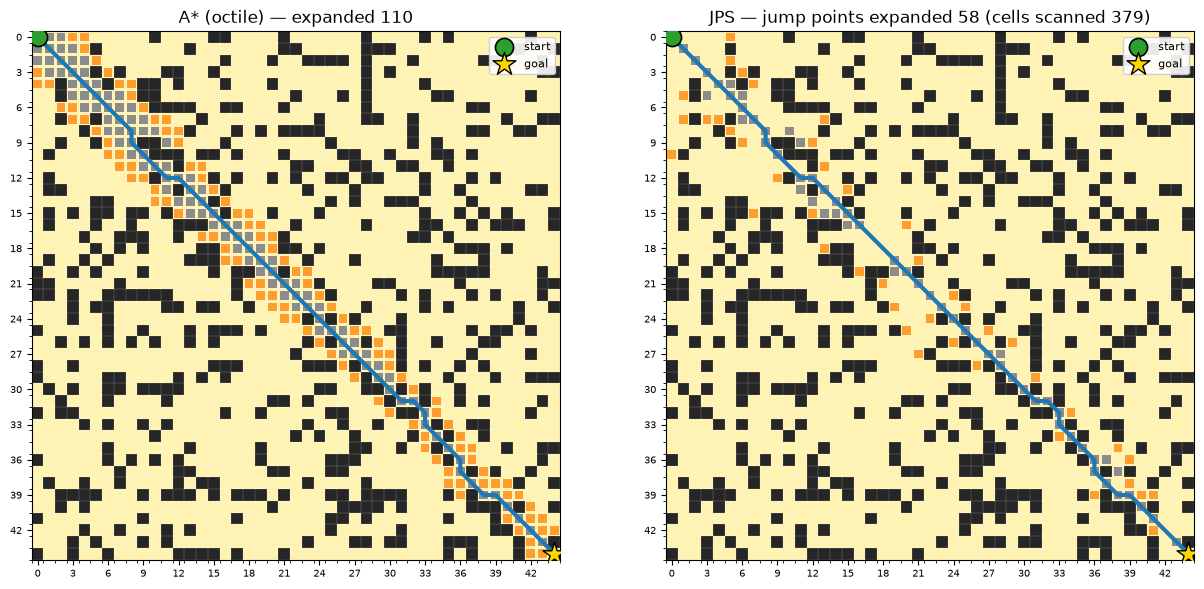

path cost: A* 63.983 | JPS 63.983
expanded: A* 110 cells vs JPS 58 jump points (379 cells peeked at while jumping).
JPS expands far fewer QUEUE nodes, but each expansion scans a run of cells — the win is real but not free, and it evaporates on weighted terrain.


In [21]:
# JPS vs A* on a uniform-cost 8-connected map (JPS's home turf).
grid = create_random_obstacles(45, 45, 0.25, seed=17, eight=True)
START, GOAL = (0, 0), (44, 44)

res_ast = a_star(grid, START, GOAL, h_octile)
res_jps = jump_point_search(grid, START, GOAL)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
draw_state(grid, res_ast, ax=axes[0]); draw_start_goal(axes[0], START, GOAL)
draw_state(grid, res_jps, ax=axes[1]); draw_start_goal(axes[1], START, GOAL)
axes[0].set_title(f"A* (octile) — expanded {res_ast.expanded}")
axes[1].set_title(f"JPS — jump points expanded {res_jps.expanded} "
                 f"(cells scanned {res_jps.scanned})")
plt.show()

print(f"path cost: A* {res_ast.path_cost:.3f} | JPS {res_jps.path_cost:.3f}")
assert math.isclose(res_ast.path_cost, res_jps.path_cost, rel_tol=1e-9), \
    "on uniform grids JPS is optimal, so costs must match A*"
print(f"expanded: A* {res_ast.expanded} cells vs JPS {res_jps.expanded} jump points"
      f" ({res_jps.scanned} cells peeked at while jumping)."
      "\nJPS expands far fewer QUEUE nodes, but each expansion scans a run of cells —"
      " the win is real but not free, and it evaporates on weighted terrain.")

## 14. Theta* — Any-Angle Path Planning

A* on a grid can only move in 4 or 8 directions, so its paths zig-zag even
when free space allows a straight line. Theta* fixes that: while expanding a
neighbor, it checks **line of sight** from the *parent* — if the parent can
see the neighbor directly, the current node is bypassed and a straight
segment is used.

```text
A*:      grid-constrained staircase      Theta*:  straight where possible
```

Assumptions stated openly: uniform costs (a straight segment of length L
costs L), free space between grid cells, and line of sight via a Bresenham
ray. The demo overlays both paths — Theta*'s is typically shorter and
cheaper, though not guaranteed optimal.

In [22]:
def line_of_sight(grid, a, b):
    """Bresenham ray a -> b; True if every cell it touches is passable.

    (Assumption: free space between grid cells is free — a standard Theta*
    simplification, consistent with 8-connected corner-cutting movement.)
    """
    x0, y0 = a
    x1, y1 = b
    dx, dy = abs(x1 - x0), abs(y1 - y0)
    sx = 1 if x1 >= x0 else -1
    sy = 1 if y1 >= y0 else -1
    err = dx - dy
    x, y = x0, y0
    while True:
        if not grid.passable((x, y)):
            return False
        if (x, y) == (x1, y1):
            return True
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x += sx
        if e2 < dx:
            err += dx
            y += sy


class ThetaStarSearch(AStarSearch):
    """Theta* — A* whose paths may cut corners in free space.

    While expanding neighbour nb of node n, if n's PARENT can see nb directly
    (line of sight), we attach nb to the parent instead: the path skips n and
    runs straight. Paths are 'any-angle', not staircase-constrained.

    Assumptions (stated, not hidden): uniform costs — a straight segment of
    Euclidean length L costs L — and free space between cells.
    """

    name = "Theta*"

    def _seg_cost(self, a, b):
        return math.dist(a, b) * self.grid.cost[b]      # uniform-map simplification

    def _expand(self, node):
        parent = self.came_from.get(node, node)          # start is its own parent
        for nb in self.grid.neighbors(node):
            if nb in self.closed:
                continue
            if line_of_sight(self.grid, parent, nb):
                tentative = self.g[parent] + self._seg_cost(parent, nb)
                if tentative < self.g.get(nb, math.inf):
                    self.g[nb] = tentative
                    self.came_from[nb] = parent          # shortcut: bypass node
                    self._push(nb)
            else:
                tentative = self.g[node] + self.grid.move_cost(node, nb)
                if tentative < self.g.get(nb, math.inf):
                    self.g[nb] = tentative
                    self.came_from[nb] = node
                    self._push(nb)


def theta_star(grid, start, goal, heuristic=None):
    return ThetaStarSearch(grid, start, goal, heuristic or h_octile).run()

print("Theta* ready (uniform-cost grids)")

Theta* ready (uniform-cost grids)


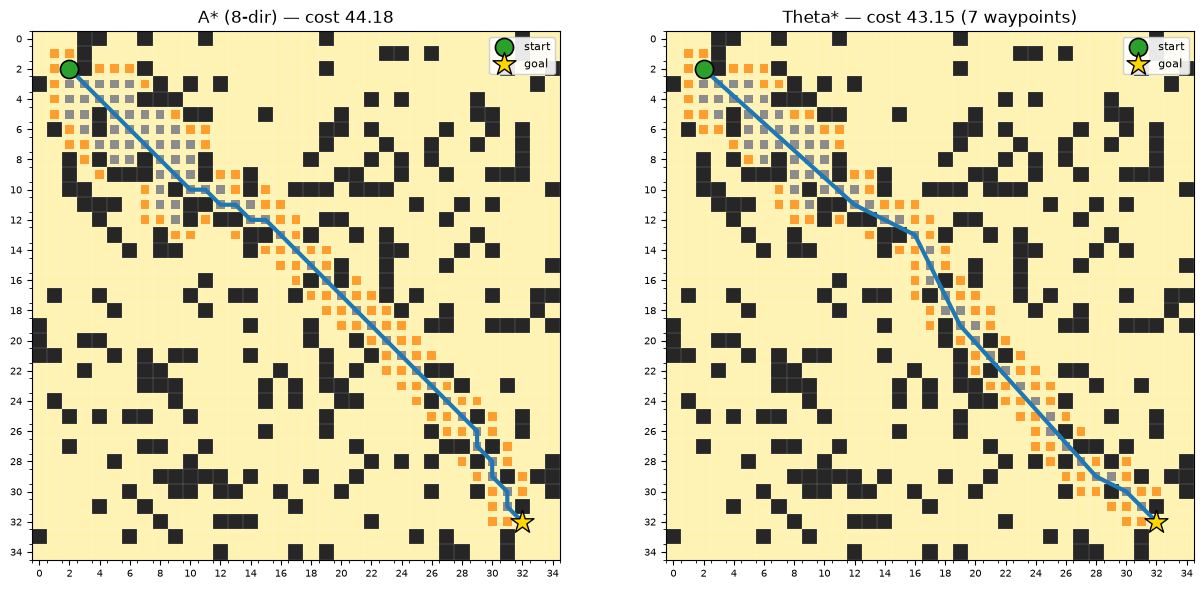

A* path: 34 grid cells, cost 44.18
Theta* path: 7 waypoints (jumping over grid corners), cost 43.15
Straight segments are only legal because line_of_sight was checked along each one (Bresenham ray). Theta* is not optimal, but it is usually cheaper and smoother than a grid staircase — which matters for real robot motion.


In [23]:
# Theta* vs A*: any-angle paths beat grid staircases.
grid = create_random_obstacles(35, 35, 0.22, seed=5, eight=True)
START, GOAL = (2, 2), (32, 32)

res_ast = a_star(grid, START, GOAL, h_octile)
res_theta = theta_star(grid, START, GOAL)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
draw_state(grid, res_ast, ax=axes[0]); draw_start_goal(axes[0], START, GOAL)
draw_state(grid, res_theta, ax=axes[1]); draw_start_goal(axes[1], START, GOAL)
axes[0].set_title(f"A* (8-dir) — cost {res_ast.path_cost:.2f}")
axes[1].set_title(f"Theta* — cost {res_theta.path_cost:.2f} "
                 f"({len(res_theta.path)} waypoints)")
plt.show()

print(f"A* path: {len(res_ast.path)} grid cells, cost {res_ast.path_cost:.2f}")
print(f"Theta* path: {len(res_theta.path)} waypoints (jumping over grid corners), "
      f"cost {res_theta.path_cost:.2f}")
print("Straight segments are only legal because line_of_sight was checked along each"
      " one (Bresenham ray). Theta* is not optimal, but it is usually cheaper and"
      " smoother than a grid staircase — which matters for real robot motion.")

## 15. Interactive Algorithm Explorer

Everything so far in one panel. Choose a preset, size, seed, algorithm,
heuristic and movement mode, then **Generate Map** and drive the search:
**Step** one expansion, **Run** to completion, or press **▶ Play** for
animated stepping (Pause stops it). Add/remove obstacles mid-experiment and
**Replan**; **Compare** runs the five classic algorithms on the current map
and prints a results table.

Legend: green = START, gold star = GOAL, orange = OPEN (frontier), grey =
CLOSED, red = CURRENT, blue = PATH, dark cells = obstacles.

In [38]:
import ast

class AlgorithmExplorer:
    """The lab's main panel: pick a world and an algorithm, then drive the search."""

    # class names resolved lazily (globals of the notebook), so algorithms whose
    # sections appear later still appear in the dropdown from the start
    ALGOS = {
        "BFS": ("BFSSearch", {}),
        "DFS": ("DFSSearch", {}),
        "Dijkstra": ("DijkstraSearch", {}),
        "Greedy Best-First": ("GreedyBestFirstSearch", {}),
        "A*": ("AStarSearch", {}),
        "Bidirectional Dijkstra": ("BidirectionalSearch", {"mode": "dijkstra"}),
        "Bidirectional A*": ("BidirectionalSearch", {"mode": "astar"}),
        "JPS": ("JPSSearch", {}),
        "Theta*": ("ThetaStarSearch", {}),
        "D* Lite": ("DStarLite", {}),
    }

    def __init__(self, rows=25, cols=25, seed=42):
        self.added = []
        self.out = widgets.Output()
        self.stats = widgets.HTML()
        w = self.w = {}
        w["rows"] = widgets.BoundedIntText(value=rows, min=4, max=200, description="Rows")
        w["cols"] = widgets.BoundedIntText(value=cols, min=4, max=200, description="Cols")
        w["preset"] = widgets.Dropdown(options=list(PRESETS), value="Random Obstacles", description="Preset")
        w["density"] = widgets.FloatSlider(value=0.25, min=0.0, max=0.6, step=0.05, description="Density")
        w["seed"] = widgets.BoundedIntText(value=seed, min=0, max=9999, description="Seed")
        w["algo"] = widgets.Dropdown(options=list(self.ALGOS), value="A*", description="Algorithm")
        w["heur"] = widgets.Dropdown(options=list(HEURISTICS), value="cost-aware", description="Heuristic")
        w["move"] = widgets.Dropdown(options=["4-connected", "8-connected"], value="4-connected", description="Movement")
        w["start"] = widgets.Text(value="(0, 0)", description="Start")
        w["goal"] = widgets.Text(value="(max, max)", description="Goal")

        w["generate"] = widgets.Button(description="Generate Map", button_style="primary")
        w["reset"] = widgets.Button(description="Reset")
        w["step"] = widgets.Button(description="Step", button_style="info")
        w["run"] = widgets.Button(description="Run", button_style="success")
        w["pause"] = widgets.Button(description="Pause")
        self.play = widgets.Play(interval=120, min=0, max=10**9, step=1)
        w["add_ob"] = widgets.Button(description="Add Obstacle")
        w["rm_ob"] = widgets.Button(description="Remove Obstacle")
        w["replan"] = widgets.Button(description="Replan", button_style="warning")
        w["compare"] = widgets.Button(description="Compare", button_style="danger")

        w["generate"].on_click(self.on_generate)
        w["reset"].on_click(lambda _: self.new_search())
        w["step"].on_click(self.on_step)
        w["run"].on_click(lambda _: (self.new_search(), self.search.run(), self.render())[-1])
        w["pause"].on_click(lambda _: setattr(self.play, "playing", False))
        self.play.observe(self.on_play, names="value")
        w["add_ob"].on_click(self.on_add_ob)
        w["rm_ob"].on_click(self.on_rm_ob)
        w["replan"].on_click(self.on_replan)
        w["compare"].on_click(self.on_compare)

        top = widgets.HBox([w["rows"], w["cols"], w["preset"], w["density"], w["seed"]])
        mid = widgets.HBox([w["start"], w["goal"], w["algo"], w["heur"], w["move"]])
        btns = widgets.HBox([w["generate"], w["reset"], w["step"], w["run"],
                             self.play, w["pause"], w["add_ob"], w["rm_ob"],
                             w["replan"], w["compare"]])
        display(widgets.VBox([top, mid, btns, self.stats]), self.out)
        self.on_generate(None)

    # -- helpers -------------------------------------------------------------
    def _cell(self, text, fallback):
        try:
            v = ast.literal_eval(text.strip())
            r, c = int(v[0]), int(v[1])
            if self.grid.in_bounds((r, c)):
                return (r, c)
        except Exception:
            pass
        return fallback

    def endpoints(self):
        s = self._cell(self.w["start"].value, (0, 0))
        g = self._cell(self.w["goal"].value,
                       (self.grid.rows - 1, self.grid.cols - 1))
        self.grid.unblock(s)
        self.grid.unblock(g)
        return s, g

    def new_search(self):
        s, g = self.endpoints()
        hname = self.w["heur"].value
        h = HEURISTICS["cost-aware"] if hname not in HEURISTICS else HEURISTICS[hname]
        cls_name, kwargs = self.ALGOS[self.w["algo"].value]
        cls = globals().get(cls_name)
        if cls is None:
            with self.out:
                clear_output(wait=True)
                print(f"{cls_name} is defined in a later section — run that cell first.")
            self.search = None
            return
        try:
            self.search = cls(self.grid, s, g, h, **kwargs)
        except ValueError as e:                       # e.g. JPS on weighted terrain
            with self.out:
                clear_output(wait=True)
                print(f"cannot run {self.w['algo'].value} here: {e}")
            self.search = None
            return
        self.render()

    # -- callbacks --------------------------------------------------------------
    def on_generate(self, _):
        rows, cols = self.w["rows"].value, self.w["cols"].value
        eight = self.w["move"].value == "8-connected"
        preset = self.w["preset"].value
        if preset in ("Random Obstacles", "Dense Obstacles"):
            density = 0.45 if preset == "Dense Obstacles" else self.w["density"].value
            self.grid = create_random_obstacles(rows, cols, density,
                                                self.w["seed"].value, eight)
        else:
            self.grid = PRESETS[preset](rows, cols, self.w["seed"].value, eight)
        self.added = []
        if self.w["goal"].value == "(max, max)":
            self.w["goal"].value = f"({self.grid.rows - 1}, {self.grid.cols - 1})"
        self.new_search()

    def on_step(self, _):
        if self.search is None:
            self.new_search()
        if self.search is not None:
            self.search.step()
            self.render()

    def on_play(self, change):
        self.on_step(None)

    def on_add_ob(self, _):
        if self.grid is None:
            return
        free = [(r, c) for r in range(self.grid.rows) for c in range(self.grid.cols)
                if self.grid.passable((r, c))]
        if free:
            cell = free[hash((self.w["seed"].value, len(self.added))) % len(free)]
            self.grid.block(cell)
            self.added.append(cell)
            self.render()

    def on_rm_ob(self, _):
        if self.added:
            self.grid.unblock(self.added.pop())
            self.render()

    def on_replan(self, _):
        if self.grid is not None:
            self.new_search()
            if self.search is not None:
                self.search.run()
                self.render()

    def on_compare(self, _):
        s, g = self.endpoints()
        rows = []
        for name, fn in (("BFS", bfs), ("DFS", dfs), ("Dijkstra", dijkstra),
                         ("Greedy Best-First", greedy_best_first), ("A*", a_star)):
            t0 = time.perf_counter()
            r = fn(self.grid, s, g)
            rows.append({"algorithm": name, "status": r.status,
                         "cost": round(r.path_cost, 2) if r.path_cost else None,
                         "path cells": len(r.path) if r.path else 0,
                         "expanded": r.expanded,
                         "ms": round((time.perf_counter() - t0) * 1000, 1)})
        with self.out:
            clear_output(wait=True)
            display(pd.DataFrame(rows))
            fig, ax = draw_state(self.grid, title="map used for comparison")
            draw_start_goal(ax, s, g)
            plt.show()

    # -- drawing -------------------------------------------------------------------
    def render(self):
        st = self.search
        with self.out:
            clear_output(wait=True)
            if self.grid is None:
                print("generate a map first")
                return
            if st is None:
                fig, ax = draw_state(self.grid)
                draw_start_goal(ax, (0, 0), (self.grid.rows - 1, self.grid.cols - 1))
                plt.show()
            else:
                state = st.snapshot() if hasattr(st, "snapshot") else st
                fig, ax = draw_state(self.grid, state)
                s, g = self.endpoints()
                draw_start_goal(ax, s, g)
                plt.show()
                cur = state.current
                g_of = state.g.get(cur) if cur is not None else None
                info = (f"<b>{state.name}</b> · status <b>{state.status}</b>"
                        f" · cost <b>{state.path_cost if state.path_cost is None else round(state.path_cost, 2)}</b>"
                        f" · path cells {len(state.path) if state.path else 0}"
                        f" · expanded <b>{state.expanded}</b>"
                        f" · current {cur} g={round(g_of, 2) if g_of is not None else '-'}"
                        f" · goal {self.w['goal'].value}")
                self.stats.value = info
                if hasattr(st, "discover_change"):
                    print("D* Lite plans in one incremental pass here — its interactive"
                          " repair loop lives in Section 20 (Robot Simulation).")


explorer = AlgorithmExplorer()

Output()

## 16. Obstacles and Unreachable Goals

Obstacles are cells with infinite traversal cost. Two situations matter:

1. **Rerouting** — a wall blocks the direct route; the algorithm must flow
   around it.
2. **No path exists** — a wall seals the goal off completely. A correct
   implementation must *report* that, not hang or crash.

Every algorithm here returns `status = "no path"` with an empty path when the
goal is unreachable, and the validation suite in Section 30 checks exactly
that. Path validity is also checkable mechanically: consecutive cells must be
neighbors and passable — `validate_path` does this after every demo.

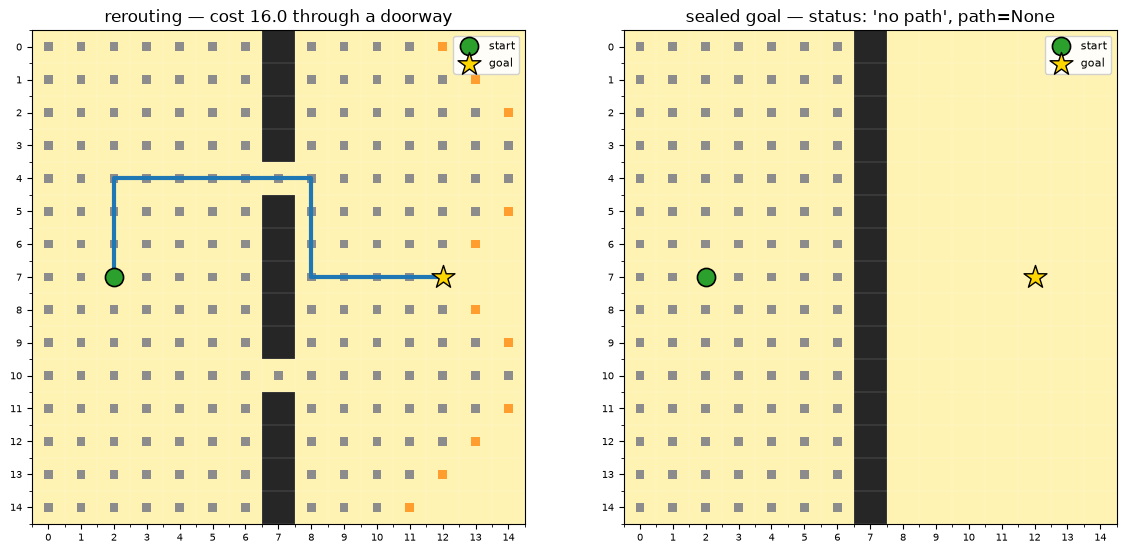

Unreachable goal handled by every algorithm: status='no path', no crash, no hang.


In [25]:
# Case 1: reroute around a wall. Case 2: goal sealed off -> "no path".
def wall_case():
    m = create_empty_grid(15, 15)
    for r in range(15):
        if r not in (4, 10):                    # two doorways
            m.block((r, 7))
    return m, (7, 2), (7, 12)

def sealed_case():
    m = create_empty_grid(15, 15)
    for r in range(15):
        m.block((r, 7))                         # solid wall: no route exists
    return m, (7, 2), (7, 12)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.6))
m, s, g = wall_case()
res = dijkstra(m, s, g)
draw_state(m, res, ax=axes[0]); draw_start_goal(axes[0], s, g)
axes[0].set_title(f"rerouting — cost {res.path_cost:.1f} through a doorway")
m2, s2, g2 = sealed_case()
res2 = dijkstra(m2, s2, g2)
draw_state(m2, res2, ax=axes[1]); draw_start_goal(axes[1], s2, g2)
axes[1].set_title(f"sealed goal — status: '{res2.status}', path={res2.path}")
plt.show()

for algo in (bfs, dfs, dijkstra, greedy_best_first, a_star):
    r = algo(m2, s2, g2)
    assert r.status == "no path" and r.path is None
print("Unreachable goal handled by every algorithm: status='no path', no crash, no hang.")

## 17. Cost Maps — "Longer but Cheaper"

Real terrain is not uniform: gravel costs more than pavement, tall grass
more than gravel. A **cost map** lets every cell carry its own traversal
cost, and the optimal path may be **longer in steps but cheaper overall**:

```text
shorter but expensive  vs  longer but cheap
```

(Language note: a high-cost cell models *expensive traversal* — energy, time,
risk of getting stuck — we only call it "higher cost", not "dangerous",
unless a model explicitly represents danger.)

The visualization colors cells by terrain cost. Watch Dijkstra route *around*
an expensive ridge through a cheap valley even when the valley is farther in
steps. Note how the manhattan heuristic becomes **inadmissible** here — the
demo shows A*-manhattan possibly returning a costlier path than Dijkstra,
while A*-cost-aware still agrees with Dijkstra.

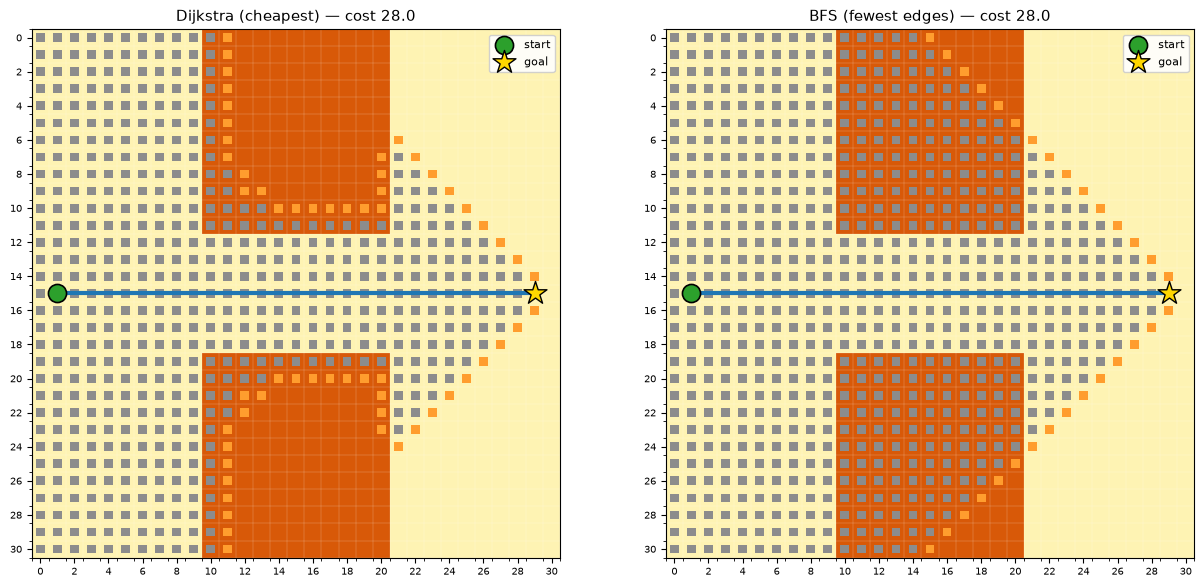

Dijkstra: 29 cells, cost 28.0 — threads the cheap valley
BFS:      29 cells, cost 28.0 — straight across the ridge
BFS pays 1.0x more for fewer steps: 'longer but cheaper' beats 'shorter but expensive'.

A* manhattan cost 28.00 (>= optimum 28.00: yes)
A* cost-aware cost 28.00 — exactly optimal, as admissibility guarantees.


In [26]:
# Weighted terrain: the cheap valley beats the expensive short cut.
grid = create_empty_grid(31, 31)
grid.cost[:, 10:21] = 8.0          # an expensive ridge across the middle
grid.cost[12:19, 10:21] = 1.0      # ...with a cheap valley through it
START, GOAL = (15, 1), (15, 29)

res_dij = dijkstra(grid, START, GOAL)
res_bfs = bfs(grid, START, GOAL)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, res, cap in ((axes[0], res_dij, "Dijkstra (cheapest)"),
                     (axes[1], res_bfs, "BFS (fewest edges)")):
    draw_state(grid, res, ax=ax, title=f"{cap} — cost {res.path_cost:.1f}")
    draw_start_goal(ax, START, GOAL)
plt.show()

print(f"Dijkstra: {len(res_dij.path)} cells, cost {res_dij.path_cost:.1f} — threads the cheap valley")
print(f"BFS:      {len(res_bfs.path)} cells, cost {res_bfs.path_cost:.1f} — straight across the ridge")
print(f"BFS pays {res_bfs.path_cost / res_dij.path_cost:.1f}x more for fewer steps:"
      " 'longer but cheaper' beats 'shorter but expensive'.")

# heuristic admissibility on this weighted map
ref = res_dij.path_cost
man = a_star(grid, START, GOAL, h_manhattan).path_cost
caw = a_star(grid, START, GOAL, h_cost_aware).path_cost
print(f"\nA* manhattan cost {man:.2f} (>= optimum {ref:.2f}: "
      f"{'yes' if man >= ref - 1e-9 else 'NO — suboptimal!'})")
assert math.isclose(caw, ref)
print(f"A* cost-aware cost {caw:.2f} — exactly optimal, as admissibility guarantees.")

## 18. Dynamic Environments

Real environments change: doors close, furniture moves, other robots cross
your path. The navigation loop becomes:

```text
STATIC MAP → robot navigates → environment changes
     → robot detects change → replan → continue toward goal
```

The key operational question is *what to do when the current route becomes
invalid*. The blunt instrument is **replan from scratch** (run A* again from
the robot's position). The elegant one is incremental replanning — D* Lite,
next section. First, the blunt version, so we have a baseline to measure
against.

old route still valid after the change? False  -> must replan


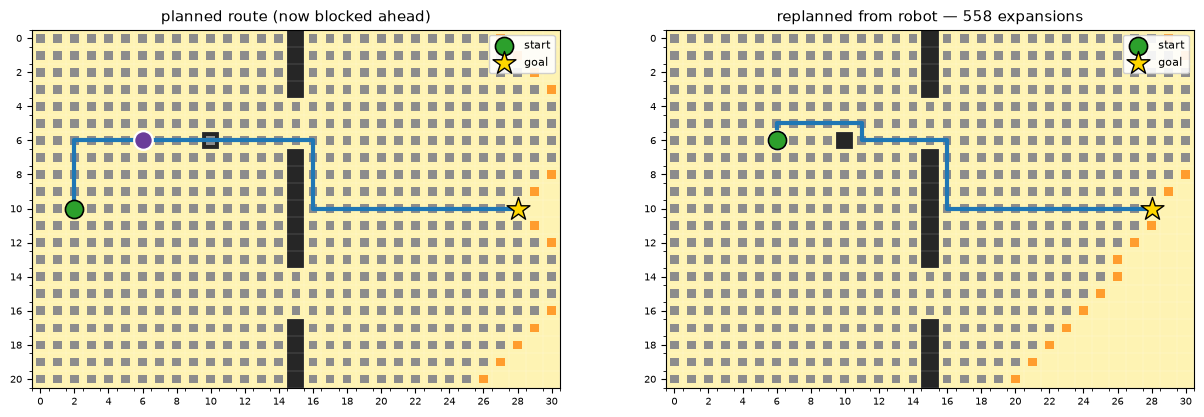

original plan: cost 34.0, expanded 602
replan from robot position: cost 28.0, expanded 558

A* from scratch throws away everything it knew. D* Lite (next) repairs instead.


In [27]:
# The blunt instrument: replan from scratch when the world changes.
grid = create_empty_grid(21, 31)
for r in range(21):
    if r not in (4, 5, 6) and r not in (14, 15, 16):   # two gaps in a wall
        grid.block((r, 15))
START, GOAL = (10, 2), (10, 28)

plan = dijkstra(grid, START, GOAL)
first_cost, first_exp = plan.path_cost, plan.expanded
robot = START
for cell in plan.path[1:9]:                # walk a few cells
    robot = cell
    grid.unblock(cell)

surprise = plan.path[12]                   # the wall gap we were heading for closes
grid.block(surprise)

ok, _ = validate_path(grid, plan.path, START, GOAL)
print(f"old route still valid after the change? {ok}  -> must replan")

replan = dijkstra(grid, robot, GOAL)       # from scratch, from the robot's position

fig, axes = plt.subplots(1, 2, figsize=(15, 6.6))
draw_state(grid, plan, ax=axes[0], robot=robot, title="planned route (now blocked ahead)")
draw_start_goal(axes[0], START, GOAL)
draw_state(grid, replan, ax=axes[1], robot=robot, title=f"replanned from robot — {replan.expanded} expansions")
draw_start_goal(axes[1], robot, GOAL)
plt.show()

print(f"original plan: cost {first_cost:.1f}, expanded {first_exp}")
print(f"replan from robot position: cost {replan.path_cost:.1f}, expanded {replan.expanded}")
print("\nA* from scratch throws away everything it knew. D* Lite (next) repairs instead.")

## 19. D* Lite — Incremental Replanning

When the world changes near the robot, most of the old search result is
still correct. **D* Lite** (Koenig & Likhachev) keeps its g-values and
repairs only what the change actually invalidated — it is an **incremental
replanning** algorithm, not "A* but faster":

- it searches **backwards** from the goal (so the robot's side stays fixable),
- it tracks two values per node: `g` (current cost estimate) and `rhs`
  (one-step lookahead), nodes where they disagree are "inconsistent" and sit
  in a priority queue,
- a key modifier `km` lets it shift priorities as the robot moves without
  rebuilding everything,
- when an edge cost changes, only the neighbors' rhs values are recomputed
  and the queue is patched.

The demo below walks a robot down a corridor, slams a wall into its planned
route, and repairs with (a) fresh A* from the robot and (b) D* Lite —
reporting how many nodes each expanded. D* Lite is *not always* cheaper; on
these maps it usually is, and we show the real numbers.

In [28]:
class DStarLite:
    """D* Lite (Koenig & Likhachev 2002), simplified for grids — genuine
    incremental replanning.

    Ideas:
      - search runs BACKWARD from the goal, so g[s] estimates cost s -> GOAL
        and everything on the robot's side stays repairable;
      - two values per node: g[s] (current belief) and rhs[s] (one-step
        lookahead, min over neighbours of c + g); nodes where g != rhs are
        'inconsistent' and live in a priority queue U;
      - when the world changes (edge costs change), only the neighbours'
        rhs values are recomputed and U is patched — the rest of the old
        search result is reused;
      - km ('key modifier') shifts priorities as the robot moves without
        rebuilding the queue.

    g-values are cost-to-goal; edges here are symmetric (average terrain
    cost), which keeps the backward bookkeeping simple.
    """

    name = "D* Lite"
    uses_heuristic = True

    def __init__(self, grid, start, goal, heuristic=None):
        self.grid = grid
        self.start_orig = start
        self.robot = start
        self.goal = goal
        self.heuristic = heuristic or h_cost_aware
        self.reset()

    def reset(self):
        self.g, self.rhs = {}, {}
        self.U = []                    # heap of (k1, k2, tie, node)
        self._best = {}                # node -> current key in U
        self._open = set()
        self._tie = count()
        self.km = 0.0
        self.last = self.robot
        self.closed_ever = set()       # for visualization
        self.expanded = 0
        self.status = "running"
        self.rhs[self.goal] = 0.0
        self._insert(self.goal)
        self.compute()

    # -- priority queue -----------------------------------------------------
    def _h(self, a, b):
        return self.heuristic(a, b, self.grid)

    def _key(self, s):
        v = min(self.g.get(s, math.inf), self.rhs.get(s, math.inf))
        return (v + self._h(self.robot, s) + self.km, v)

    def _insert(self, s):
        k = self._key(s)
        self._best[s] = k
        self._open.add(s)
        heapq.heappush(self.U, (k[0], k[1], next(self._tie), s))

    def _remove(self, s):
        self._best.pop(s, None)
        self._open.discard(s)

    def _pop(self):
        while self.U:
            k1, k2, _, s = heapq.heappop(self.U)
            if s in self._open and self._best.get(s) == (k1, k2):
                self._open.discard(s)
                self._best.pop(s, None)
                return (k1, k2), s
        return None, None

    def _top_key(self):
        while self.U:
            k1, k2, _, s = self.U[0]
            if s in self._open and self._best.get(s) == (k1, k2):
                return (k1, k2)
            heapq.heappop(self.U)
        return (math.inf, math.inf)

    def _update_vertex(self, s):
        if s != self.goal:
            best = math.inf
            for nb in self.grid.neighbors(s):
                best = min(best, self.grid.move_cost(s, nb) + self.g.get(nb, math.inf))
            self.rhs[s] = best
        if s in self._open and self.g.get(s, math.inf) != self.rhs.get(s, math.inf):
            self._remove(s)              # key changed: re-insert below
            self._insert(s)
        elif self.g.get(s, math.inf) != self.rhs.get(s, math.inf) and s not in self._open:
            self._insert(s)
        elif self.g.get(s, math.inf) == self.rhs.get(s, math.inf) and s in self._open:
            self._remove(s)

    # -- the repair loop ------------------------------------------------------
    def compute(self):
        """ComputeShortestPath: resolve inconsistencies relevant to the robot.

        _update_vertex fully recomputes rhs from the neighbours' current g,
        so both branches only need to refresh the affected vertices.
        """
        while self._top_key() < self._key(self.robot) or \
              self.rhs.get(self.robot, math.inf) != self.g.get(self.robot, math.inf):
            _, u = self._pop()
            if u is None:
                break
            self.closed_ever.add(u)
            self.expanded += 1
            if self.g.get(u, math.inf) > self.rhs.get(u, math.inf):
                self.g[u] = self.rhs[u]                       # underconsistent: fix g
                for s in self.grid.neighbors(u):
                    self._update_vertex(s)
            else:                                            # overconsistent: reset g
                self.g[u] = math.inf
                for s in list(self.grid.neighbors(u)) + [u]:
                    self._update_vertex(s)
        if self.g.get(self.robot, math.inf) == math.inf:
            self.status = "no path"
        else:
            self.status = "goal"

    # -- world changes ----------------------------------------------------------
    def discover_change(self, cell, now_blocked):
        """An edge-cost change: `cell` became an obstacle (or stopped being one).
        Only the neighbours' lookahead values are recomputed — the point of
        incremental replanning."""
        if now_blocked:
            self.grid.block(cell)
            self.rhs[cell] = math.inf
            self.g[cell] = math.inf
        else:
            self.grid.unblock(cell)
            self._update_vertex(cell)
        for n in self.grid.neighbors(cell):
            self._update_vertex(n)
        self.compute()

    def move_to(self, cell):
        """Robot moves; priorities shift via km instead of rebuilding search."""
        self.km += self._h(self.last, self.robot)
        self.last = self.robot
        self.robot = cell
        open_nodes = list(self._open)
        for s in open_nodes:                  # re-key the open set (new robot/km)
            self._remove(s)
        for s in open_nodes:
            self._insert(s)
        self.compute()

    # -- using the plan -----------------------------------------------------------
    def next_step(self):
        if self.status != "goal":
            return None
        best, best_v = None, math.inf
        for nb in self.grid.neighbors(self.robot):
            v = self.grid.move_cost(self.robot, nb) + self.g.get(nb, math.inf)
            if v < best_v:
                best, best_v = nb, v
        if best_v == math.inf:
            return None
        return best

    def path_ahead(self, limit=10_000):
        """Walk greedy on g from the robot to the goal."""
        if self.status != "goal":
            return None
        path, cur, seen = [self.robot], self.robot, {self.robot}
        while cur != self.goal and len(path) < limit:
            nxt = None
            best = math.inf
            for nb in self.grid.neighbors(cur):
                v = self.grid.move_cost(cur, nb) + self.g.get(nb, math.inf)
                if v < best:
                    best, nxt = v, nb
            if nxt is None or nxt in seen:
                return None
            path.append(nxt)
            seen.add(nxt)
            cur = nxt
        return path if cur == self.goal else None

    def snapshot(self):
        p = self.path_ahead()
        return SearchState(
            name=self.name, status=self.status, current=self.robot,
            open_set=set(self._open), closed_set=set(self.closed_ever),
            g=dict(self.g), path=p,
            path_cost=(self.g.get(self.robot) if p else None),
            expanded=self.expanded, extras={})

print("D* Lite ready — incremental replanning")

D* Lite ready — incremental replanning


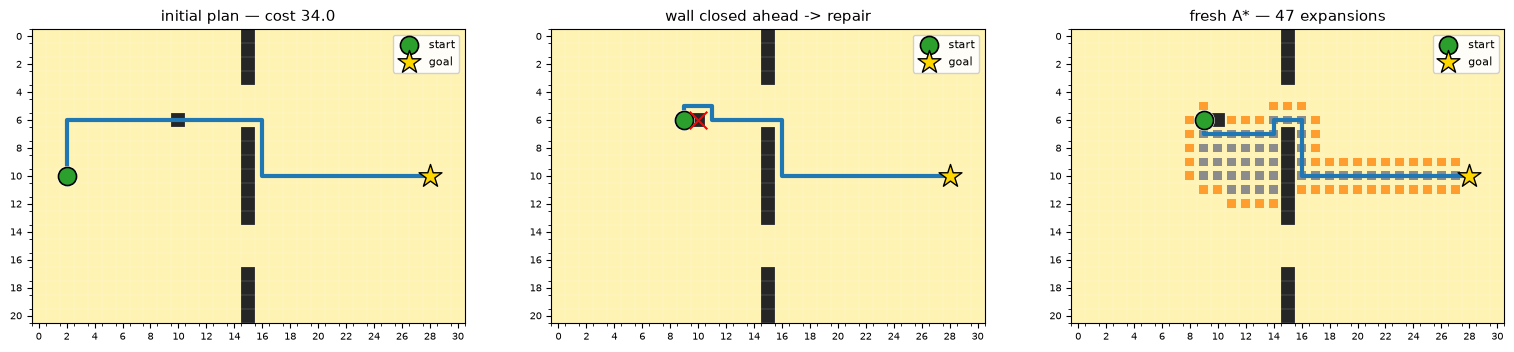

initial plan cost 34.0  (initial search expanded 248)
D* Lite repair after the wall appeared: 24 expansions, new cost 25.0
fresh A* from robot position:           47 expansions, cost 25.0

Same optimal route, a fraction of the work: D* Lite reused everything the wall didn't invalidate. (Not always this dramatic — the saving depends on where the change lands relative to the search. Measure, don't assume.)


In [29]:
# D* Lite: the same scenario, repaired incrementally.
def make_corridor_map():
    m = create_empty_grid(21, 31)
    for r in range(21):
        if r not in (4, 5, 6) and r not in (14, 15, 16):   # two gaps in the wall
            m.block((r, 15))
    return m

grid = make_corridor_map()
START, GOAL = (10, 2), (10, 28)

dsl = DStarLite(grid, START, GOAL)
initial_cost = dsl.g[START]
initial_exp = dsl.expanded
initial_path = dsl.path_ahead()

# robot follows the plan; D* Lite shifts priorities via km as it moves
robot = START
walked = []
for cell in initial_path[1:12]:
    dsl.move_to(cell)
    robot = cell
    walked.append(cell)

mid_exp = dsl.expanded

# ...and now the gap ahead slams shut
surprise = initial_path[12]
exp_before_repair = dsl.expanded
dsl.discover_change(surprise, now_blocked=True)
repair_exp = dsl.expanded - exp_before_repair
repaired_path = dsl.path_ahead()

# baseline: fresh A* from the same robot position on the same changed map
fresh = a_star(grid, robot, GOAL)

fig, axes = plt.subplots(1, 3, figsize=(19, 6.2))
draw_state(grid, ax=axes[0], robot=START, title=f"initial plan — cost {initial_cost:.1f}")
axes[0].plot([p[1] for p in initial_path], [p[0] for p in initial_path],
             color=PALETTE["path"], lw=3)
draw_start_goal(axes[0], START, GOAL)
draw_state(grid, ax=axes[1], robot=robot, title=f"wall closed ahead -> repair")
axes[1].plot([p[1] for p in repaired_path], [p[0] for p in repaired_path],
             color=PALETTE["path"], lw=3)
axes[1].scatter([surprise[1]], [surprise[0]], c="red", marker="x", s=160, zorder=8)
draw_start_goal(axes[1], robot, GOAL)
draw_state(grid, fresh, ax=axes[2], robot=robot, title=f"fresh A* — {fresh.expanded} expansions")
draw_start_goal(axes[2], robot, GOAL)
plt.show()

print(f"initial plan cost {initial_cost:.1f}  (initial search expanded {initial_exp})")
print(f"D* Lite repair after the wall appeared: {repair_exp} expansions, "
      f"new cost {dsl.g[robot]:.1f}")
print(f"fresh A* from robot position:           {fresh.expanded} expansions, "
      f"cost {fresh.path_cost:.1f}")
assert math.isclose(dsl.g[robot], fresh.path_cost, rel_tol=1e-9), \
    "D* Lite repair must preserve optimality"
print("\nSame optimal route, a fraction of the work: D* Lite reused everything the wall"
      " didn't invalidate. (Not always this dramatic — the saving depends on where the"
      " change lands relative to the search. Measure, don't assume.)")

## 20. Robot Simulation — Sensing, Discovering, Replanning

A small simulated robot puts it together:

```python
robot_position   current cell
robot_path       planned route
goal             where we're going
obstacles        what we know about
```

The robot lives in two maps at once: the **true map** (hidden obstacles) and
its **known map** (what it has seen). A short-range sensor reveals true
obstacles as the robot moves; if a newly discovered obstacle invalidates the
planned route, the robot must replan — with A* from scratch or with a D* Lite
repair, your choice, expansions counted either way.

Controls: **Plan A\*** · **Step Robot** (one cell + sensing) · **▶ Auto** ·
**Drop Obstacle Ahead** · **Clear It** · **Replan A\*** · **D\* Lite Repair**.

In [30]:
class RobotNavUI:
    """A robot with a short-range sensor: true map vs known map, replan on change."""

    SENSOR_RADIUS = 2

    def __init__(self, size=25, seed=6, reveal=0.35):
        self.goal = (size - 1, size - 1)
        self.out = widgets.Output()
        self.stats = widgets.HTML()
        self.message = "plan a route to start"
        self.last_replan = None          # ("A* from scratch" / "D* Lite repair", expansions)

        # true world: all obstacles. known world: only a fraction revealed at t=0
        self.true_grid = create_random_obstacles(size, size, 0.22, seed)
        rng = random.Random(seed + 1)
        known_blocked = {c for c in self.true_grid.blocked if rng.random() < reveal}
        self.known_grid = self.true_grid.clone()
        self.known_grid.blocked = set(known_blocked)
        self.known_grid.unblock((0, 0))
        self.known_grid.unblock(self.goal)

        self.robot = (0, 0)
        self.plan = None
        self.search = None
        self.dsl = DStarLite(self.known_grid, self.robot, self.goal)
        self.dsl_exp_at_plan = self.dsl.expanded

        w = self.w = {}
        w["plan"] = widgets.Button(description="Plan A*", button_style="success")
        w["step"] = widgets.Button(description="Step Robot", button_style="info")
        self.play = widgets.Play(interval=350, min=0, max=10**9)
        w["drop"] = widgets.Button(description="Drop Obstacle Ahead", button_style="danger")
        w["clear"] = widgets.Button(description="Clear It")
        w["re_astar"] = widgets.Button(description="Replan A* (scratch)")
        w["re_dsl"] = widgets.Button(description="D* Lite Repair", button_style="warning")
        w["plan"].on_click(self.on_plan)
        w["step"].on_click(lambda _: self.step_robot())
        self.play.observe(lambda ch: self.step_robot(), names="value")
        w["drop"].on_click(self.on_drop)
        w["clear"].on_click(self.on_clear)
        w["re_astar"].on_click(self.on_replan_astar)
        w["re_dsl"].on_click(self.on_replan_dsl)

        display(widgets.VBox([widgets.HBox([w["plan"], w["step"], self.play,
                                            w["drop"], w["clear"]]),
                              widgets.HBox([w["re_astar"], w["re_dsl"]]),
                              self.stats]), self.out)
        self.render()

    # -- sensing -----------------------------------------------------------------
    def sense(self):
        """Reveal true obstacles within SENSOR_RADIUS of the robot."""
        found = []
        r0, c0 = self.robot
        for r in range(r0 - self.SENSOR_RADIUS, r0 + self.SENSOR_RADIUS + 1):
            for c in range(c0 - self.SENSOR_RADIUS, c0 + self.SENSOR_RADIUS + 1):
                cell = (r, c)
                if cell in self.true_grid.blocked and cell not in self.known_grid.blocked:
                    self.known_grid.block(cell)
                    self.dsl.discover_change(cell, now_blocked=True)
                    found.append(cell)
        return found

    # -- actions ---------------------------------------------------------------------
    def on_plan(self, _):
        self.search = AStarSearch(self.known_grid, self.robot, self.goal)
        self.search.run()
        self.plan = list(self.search.path) if self.search.path else None
        self.message = (f"A* planned: cost {self.search.path_cost:.1f}"
                        if self.plan else "no path found on the known map!")
        self.render()

    def step_robot(self):
        if self.plan is None:
            self.on_plan(None)
        if not self.plan:
            return
        idx = self.plan.index(self.robot) if self.robot in self.plan else -1
        if idx == -1 or idx + 1 >= len(self.plan):
            self.message = "goal reached!"
            self.render()
            return
        nxt = self.plan[idx + 1]
        if not self.known_grid.passable(nxt):
            self.message = "route blocked — replan needed!"
            self.render()
            return
        self.robot = nxt
        self.dsl.move_to(nxt)
        found = self.sense()
        if found:
            blocked_ahead = [c for c in self.plan[idx + 1:] if not self.known_grid.passable(c)]
            if blocked_ahead:
                self.message = (f"sensor saw {len(found)} new obstacle(s) — route "
                                f"invalidated, replan! (D* Lite already repaired: "
                                f"{self.dsl.status})")
        elif nxt == self.goal:
            self.message = "goal reached!"
        else:
            self.message = f"moved to {nxt}"
        self.plan = self.dsl.path_ahead() or self.plan   # follow the repaired route
        self.render()

    def on_drop(self, _):
        if not self.plan:
            return
        for cell in self.plan[self.plan.index(self.robot) + 3:]:
            if self.known_grid.passable(cell) and cell != self.goal:
                self.true_grid.block(cell)
                self.known_grid.block(cell)
                self.dsl.discover_change(cell, now_blocked=True)
                self.message = f"obstacle dropped at {cell} — D* Lite repaired, A* would replan from scratch"
                self.plan = self.dsl.path_ahead() or self.plan
                self.render()
                return

    def on_clear(self, _):
        # re-open every known obstacle that was never truly there is complex;
        # instead re-open the most recent true block near the path
        if self.plan:
            for cell in self.plan:
                if cell in self.known_grid.blocked and cell in self.true_grid.blocked:
                    self.true_grid.unblock(cell)
                    self.known_grid.unblock(cell)
                    self.dsl.discover_change(cell, now_blocked=False)
                    self.message = f"cleared {cell}"
                    self.plan = self.dsl.path_ahead() or self.plan
                    self.render()
                    return

    def on_replan_astar(self, _):
        t0 = self.dsl.expanded
        self.search = AStarSearch(self.known_grid, self.robot, self.goal)
        self.search.run()
        self.plan = list(self.search.path) if self.search.path else None
        self.last_replan = ("A* from scratch", self.search.expanded)
        self.message = f"A* replanned from {self.robot}: {self.search.expanded} expansions"
        self.render()

    def on_replan_dsl(self, _):
        before = self.dsl.expanded
        self.dsl.compute()
        self.plan = self.dsl.path_ahead()
        self.last_replan = ("D* Lite repair", self.dsl.expanded - before)
        self.message = (f"D* Lite repaired: {self.dsl.expanded - before} expansions "
                        f"(total ever: {self.dsl.expanded})")
        self.render()

    # -- drawing ---------------------------------------------------------------
    def render(self):
        with self.out:
            clear_output(wait=True)
            fig, ax = draw_state(self.known_grid, robot=self.robot,
                                 title=f"known map — robot at {self.robot}")
            if self.plan:
                ax.plot([p[1] for p in self.plan], [p[0] for p in self.plan],
                        color=PALETTE["path"], lw=3, zorder=4)
            draw_start_goal(ax, self.robot if self.robot else (0, 0), self.goal)
            plt.show()
            self.stats.value = (f"<b>{self.message}</b> · D* Lite total expansions: "
                                f"{self.dsl.expanded}"
                                + (f" · last repair: {self.last_replan[0]} "
                                   f"({self.last_replan[1]} expansions)"
                                   if self.last_replan else ""))
            print("grey cells = discovered obstacles · robot senses true obstacles"
                  " within radius 2 while moving")


robot_ui = RobotNavUI()

Output()

## 21. Large-Grid Performance

The same algorithms, measured — not argued about — on growing maps
(10² to 250², sparse obstacles, fixed seed for reproducibility):

```text
Algorithm | Grid Size | Path Cost | Path Length | Nodes Expanded | Runtime
```

Things worth watching in the results:

- Dijkstra's expansion grows with the *whole explored area*;
- a good heuristic prunes that area (how much depends on obstacle layout);
- bidirectional search digs two half-depth regions instead of one full one;
- JPS is specialized for exactly these uniform-cost maps.

Everything below is actually executed — no fabricated numbers. (500×500 is
omitted to keep the notebook quick; the code handles it, Python just takes
its time.)

,algorithm,grid,path cost,path length,expanded,runtime (s)
0,Dijkstra,10x10,13.90,12,73,0.000
1,A*,10x10,13.90,12,19,0.000
2,Greedy Best-First,10x10,13.90,12,11,0.000
3,Bidirectional Dijkstra,10x10,13.90,12,50,0.000
4,Bidirectional A*,10x10,13.90,12,27,0.000
5,JPS,10x10,13.90,9,11,0.000
6,Dijkstra,25x25,34.53,26,468,0.003
7,A*,25x25,34.53,26,42,0.000
8,Greedy Best-First,25x25,34.53,26,25,0.000
9,Bidirectional Dijkstra,25x25,34.53,26,319,0.002


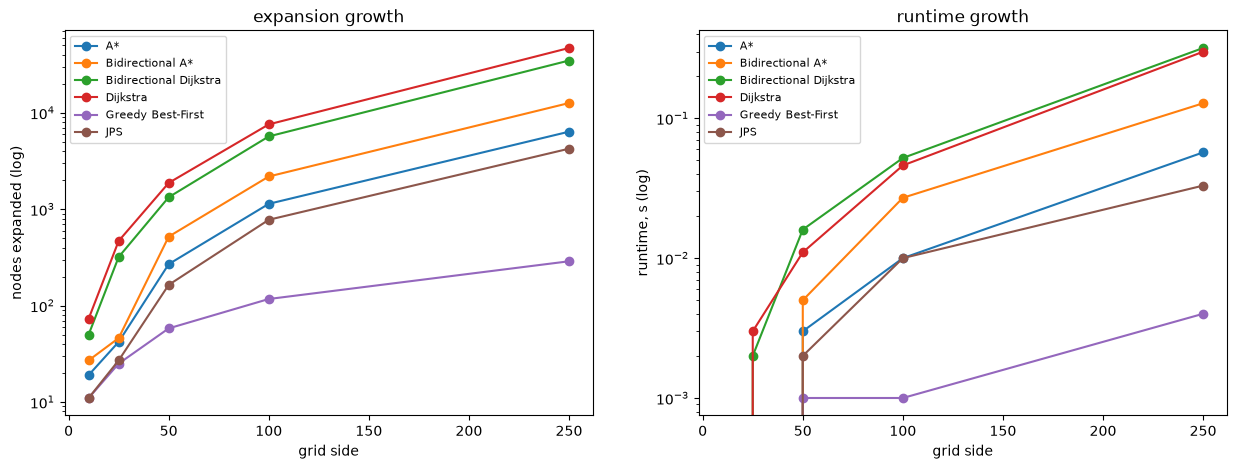

Every number above came from an actual run just now. Growth is what you should look at, not single timings — Python overhead differs from a C++ robot stack.
Note: JPS 'path length' counts jump-point WAYPOINTS, not every grid cell — the route is the same cost, just expressed with fewer stopping points.


In [31]:
# --- honest benchmarks: actually executed, never fabricated -------------------
import time

def timed(search):
    t0 = time.perf_counter()
    search.run()
    dt = time.perf_counter() - t0
    return search, dt

BENCH_SIZES = [10, 25, 50, 100, 250]

def bench_algorithms(grid, start, goal):
    out = []
    entries = [
        ("Dijkstra", lambda: DijkstraSearch(grid, start, goal)),
        ("A*", lambda: AStarSearch(grid, start, goal, h_cost_aware)),
        ("Greedy Best-First", lambda: GreedyBestFirstSearch(grid, start, goal, h_cost_aware)),
        ("Bidirectional Dijkstra", lambda: BidirectionalSearch(grid, start, goal, "dijkstra")),
        ("Bidirectional A*", lambda: BidirectionalSearch(grid, start, goal, "astar", h_cost_aware)),
        ("JPS", lambda: JPSSearch(grid, start, goal)),
    ]
    for name, make in entries:
        try:
            res, dt = timed(make())
            out.append((name, res.path_cost, len(res.path), res.expanded, dt))
        except ValueError as e:
            out.append((name, None, None, None, None))
    return out

rows = []
for size in BENCH_SIZES:
    grid = create_random_obstacles(size, size, 0.25, seed=7, eight=True)
    start, goal = (0, 0), (grid.rows - 1, grid.cols - 1)
    for name, cost, plen, exp, dt in bench_algorithms(grid, start, goal):
        rows.append({"algorithm": name, "grid": f"{size}x{size}",
                     "path cost": round(cost, 2) if cost else None,
                     "path length": plen,
                     "expanded": exp,
                     "runtime (s)": round(dt, 3) if dt is not None else None})

df_bench = pd.DataFrame(rows)
display(df_bench)

# sanity: on these uniform maps every OPTIMAL algorithm must agree on cost
# (Greedy is excluded on purpose — it is fast, not optimal)
for size in BENCH_SIZES:
    sub = df_bench[(df_bench["grid"] == f"{size}x{size}")
                   & (df_bench["algorithm"] != "Greedy Best-First")]["path cost"].dropna()
    assert sub.max() - sub.min() < 1e-6, f"cost disagreement at {size}x{size}"

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for name, grp in df_bench.groupby("algorithm"):
    if grp["expanded"].isna().all():
        continue
    axes[0].plot(grp["grid"].str.split("x").str[0].astype(int), grp["expanded"],
                 marker="o", label=name)
    axes[1].plot(grp["grid"].str.split("x").str[0].astype(int), grp["runtime (s)"],
                 marker="o", label=name)
axes[0].set_yscale("log"); axes[1].set_yscale("log")
axes[0].set_xlabel("grid side"); axes[0].set_ylabel("nodes expanded (log)")
axes[1].set_xlabel("grid side"); axes[1].set_ylabel("runtime, s (log)")
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
axes[0].set_title("expansion growth"); axes[1].set_title("runtime growth")
plt.show()
print("Every number above came from an actual run just now. Growth is what you should"
      " look at, not single timings — Python overhead differs from a C++ robot stack.")
print("Note: JPS 'path length' counts jump-point WAYPOINTS, not every grid cell —"
      " the route is the same cost, just expressed with fewer stopping points.")

## 22. RRT — Rapidly-exploring Random Tree

Robots do not live on grids. A mobile robot's state is continuous:

```text
x = 14.37, y = 8.92, theta = 1.57
```

**RRT** grows a tree through free space: sample a random point, steer the
nearest tree node toward it by a small step, connect if collision-free. The
tree bias naturally stretches toward unexplored regions. Probabilistically
complete, not optimal — it finds *a* collision-free path, not the best one.

This is a deliberately simplified demo (point robot, circular obstacles,
holonomic steering) — a teaching sketch, not a production planner.

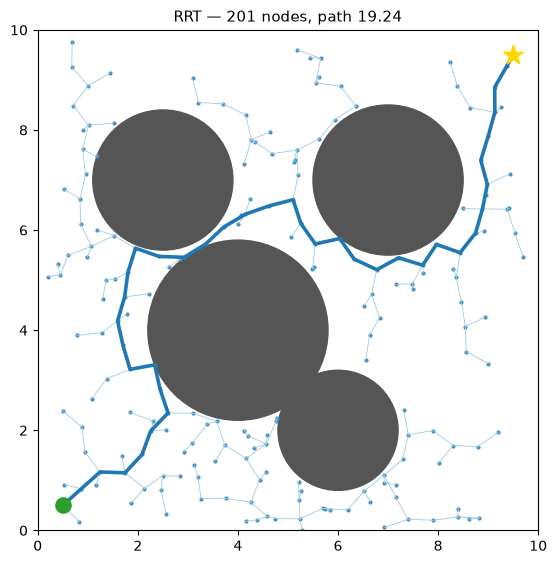

In [32]:
# --- continuous space: point robot, circular obstacles, holonomic steps -------

WORLD_BOUNDS = (0.0, 10.0)
WORLD_OBSTACLES = [(4.0, 4.0, 1.8), (7.0, 7.0, 1.5), (6.0, 2.0, 1.2), (2.5, 7.0, 1.4)]
RRT_START, RRT_GOAL = (0.5, 0.5), (9.5, 9.5)

def segment_clear(p, q, obstacles, step=0.05):
    """Collision-free straight segment? (vectorized sample of the ray)"""
    n = max(2, int(math.dist(p, q) / step) + 1)
    ts = np.linspace(0.0, 1.0, n)
    xs = p[0] + (q[0] - p[0]) * ts
    ys = p[1] + (q[1] - p[1]) * ts
    for cx, cy, r in obstacles:
        if np.any((xs - cx) ** 2 + (ys - cy) ** 2 < r ** 2):
            return False
    return True

def steer(near, sample, step_size):
    d = math.dist(near, sample)
    if d <= step_size:
        return sample
    t = step_size / d
    return (near[0] + (sample[0] - near[0]) * t, near[1] + (sample[1] - near[1]) * t)

def chain_from(parent, node):
    out = []
    while node is not None:
        out.append(node)
        node = parent[node]
    return out[::-1]

def rrt(start, goal, obstacles, bounds=WORLD_BOUNDS, n_iter=800,
        step_size=0.5, goal_bias=0.05, seed=0):
    """Rapidly-exploring Random Tree. Returns (parent, path or None)."""
    rng = random.Random(seed)
    parent = {start: None}
    nodes = [start]
    for _ in range(n_iter):
        sample = goal if rng.random() < goal_bias else \
            (rng.uniform(*bounds), rng.uniform(*bounds))
        near = min(nodes, key=lambda n: math.dist(n, sample))
        new = steer(near, sample, step_size)
        if new not in parent and segment_clear(near, new, obstacles):
            parent[new] = near
            nodes.append(new)
            if math.dist(new, goal) <= step_size and segment_clear(new, goal, obstacles):
                parent[goal] = new
                return parent, chain_from(parent, goal)
    return parent, None

def draw_continuous(parent, path, obstacles, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6.5, 6.5))
    for cx, cy, r in obstacles:
        ax.add_patch(plt.Circle((cx, cy), r, color="#555555"))
    for node, par in parent.items():
        if par is not None:
            ax.plot([par[0], node[0]], [par[1], node[1]], color="#9ecae1", lw=0.6)
    ax.scatter([n[0] for n in parent], [n[1] for n in parent], s=4, color="#4292c6")
    if path:
        ax.plot([p[0] for p in path], [p[1] for p in path], color=PALETTE["path"], lw=2.6)
    ax.scatter(*RRT_START, c=PALETTE["start"], s=120, zorder=6, marker="o")
    ax.scatter(*RRT_GOAL, c=PALETTE["goal"], s=220, zorder=6, marker="*")
    ax.set_xlim(*WORLD_BOUNDS); ax.set_ylim(*WORLD_BOUNDS)
    ax.set_aspect("equal"); ax.set_title(title, fontsize=11)

rrt_parent, rrt_path = rrt(RRT_START, RRT_GOAL, WORLD_OBSTACLES, seed=1)
draw_continuous(rrt_parent, rrt_path, WORLD_OBSTACLES,
                f"RRT — {len(rrt_parent)} nodes"
                + (f", path {sum(math.dist(a,b) for a,b in zip(rrt_path, rrt_path[1:])):.2f}"
                   if rrt_path else ", no path this seed"))
plt.show()
if rrt_path is None:
    print("RRT is probabilistically complete, not guaranteed per run — rerun/raise n_iter.")

## 23. RRT* — Asymptotically Optimal RRT

RRT* adds two local operations to every new node:

1. **choose parent**: connect not to the nearest node but to the cheapest
   node within a radius,
2. **rewire**: re-parent nearby nodes through the new node when that makes
   them cheaper.

The result: as samples → ∞ the best path cost converges toward optimal.
On any *finite* run, "RRT* always finds the best practical path" would be
false — it usually beats RRT with more computation per sample. The demo runs
both on the same world and overlays them.

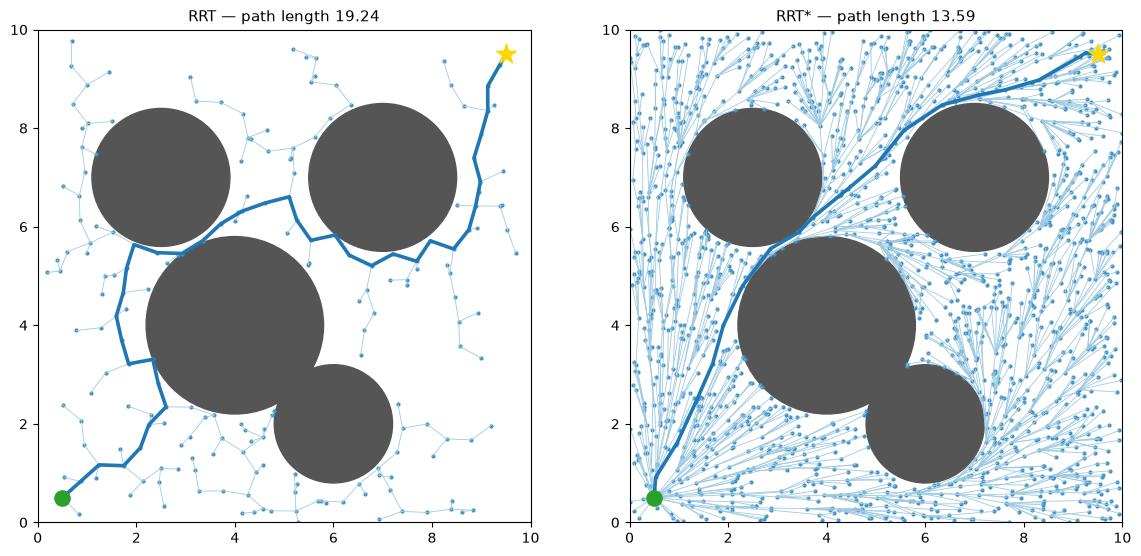

RRT  path length: 19.24
RRT* path length: 13.59
RRT* usually wins with enough iterations (asymptotic optimality) — on any single finite run neither is guaranteed the best practical path.


In [33]:
def rrt_star(start, goal, obstacles, bounds=WORLD_BOUNDS, n_iter=2500,
             step_size=0.5, goal_bias=0.05, radius=1.0, seed=0):
    """RRT* = RRT + 'choose best parent' + 'rewire neighbours'.

    Every node carries its tree cost in a dict, so parent choice and rewiring
    cost O(neighbours) per sample — no chain walks. Simplification (stated
    openly): rewiring updates only the rewired node's cost, not its whole
    subtree — fine for a demo, not for a production planner.
    """
    rng = random.Random(seed)
    parent = {start: None}
    cost = {start: 0.0}
    radius_sq = radius * radius
    best_path, best_cost = None, math.inf
    for _ in range(n_iter):
        sample = goal if rng.random() < goal_bias else \
            (rng.uniform(*bounds), rng.uniform(*bounds))
        near = min(parent, key=lambda n: (n[0]-sample[0])**2 + (n[1]-sample[1])**2)
        new = steer(near, sample, step_size)
        if new in parent or not segment_clear(near, new, obstacles):
            continue
        # nearby candidates: distance prefilter FIRST, collision check second
        visible = [n for n in parent
                   if (n[0]-new[0])**2 + (n[1]-new[1])**2 <= radius_sq
                   and segment_clear(n, new, obstacles)]
        if not visible:
            continue
        # choose parent: cheapest VISIBLE node, not merely the closest one
        best = min(visible, key=lambda n: cost[n] + math.dist(n, new))
        parent[new] = best
        cost[new] = cost[best] + math.dist(best, new)
        # rewire: route neighbours through `new` when that is cheaper
        for n in visible:
            if n is best or n == start:
                continue
            through = cost[new] + math.dist(new, n)
            if through < cost[n]:
                parent[n] = new
                cost[n] = through
        if math.dist(new, goal) <= step_size and segment_clear(new, goal, obstacles):
            c = cost[new] + math.dist(new, goal)
            if c < best_cost:
                best_cost, best_path = c, chain_from(parent, new) + [goal]
    return parent, best_path

rrts_parent, rrts_path = rrt_star(RRT_START, RRT_GOAL, WORLD_OBSTACLES, seed=1)
pl = lambda p: sum(math.dist(a, b) for a, b in zip(p, p[1:]))

fig, axes = plt.subplots(1, 2, figsize=(14, 6.4))
draw_continuous(rrt_parent, rrt_path, WORLD_OBSTACLES,
                f"RRT — path length {pl(rrt_path):.2f}" if rrt_path else "RRT — no path", ax=axes[0])
draw_continuous(rrts_parent, rrts_path, WORLD_OBSTACLES,
                f"RRT* — path length {pl(rrts_path):.2f}" if rrts_path else "RRT* — no path", ax=axes[1])
plt.show()
if rrt_path and rrts_path:
    print(f"RRT  path length: {pl(rrt_path):.2f}")
    print(f"RRT* path length: {pl(rrts_path):.2f}")
    print("RRT* usually wins with enough iterations (asymptotic optimality) — on any"
          " single finite run neither is guaranteed the best practical path.")
else:
    print("RRT* did not reach the goal with this seed/budget — sampling planners are"
          " probabilistic. Raise n_iter or change the seed and re-run the cell.")

## 24. PRM — Probabilistic Roadmap

PRM decouples sampling from querying: scatter N collision-free samples,
connect each to its k nearest collision-free neighbors, and you get a
**roadmap graph** of free space. Queries then reduce to connecting
start/goal into the roadmap and running a graph search — our own hand-written
Dijkstra queries it below.

PRM shines when many queries answer against the same static map. In truly
dynamic environments the roadmap itself goes stale — that's where
grid-based replanners like D* Lite earn their keep.

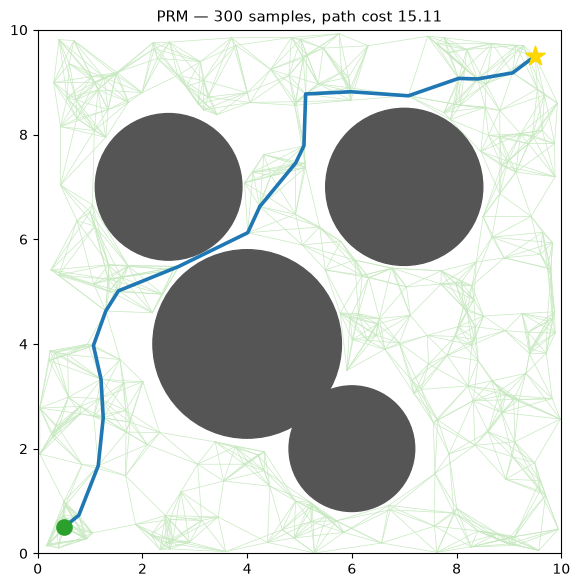

PRM queried with our own graph Dijkstra: cost 15.11.
One roadmap, many queries — that's the deal. If the world changes, the roadmap itself must be rebuilt, unlike D* Lite's incremental repairs.


In [34]:
def graph_dijkstra(adj, start, goal):
    """Hand-written Dijkstra over a small generic graph {node: {nbr: w}}."""
    dist = {start: 0.0}
    came = {}
    heap = [(0.0, start)]
    seen = set()
    while heap:
        d, u = heapq.heappop(heap)
        if u in seen:
            continue
        seen.add(u)
        if u == goal:
            path = [goal]
            while path[-1] != start:
                path.append(came[path[-1]])
            return path[::-1], d
        for v, w in adj.get(u, {}).items():
            if d + w < dist.get(v, math.inf):
                dist[v] = d + w
                came[v] = u
                heapq.heappush(heap, (d + w, v))
    return None, math.inf

def prm(start, goal, obstacles, n=300, k=8, bounds=WORLD_BOUNDS, seed=0):
    """Probabilistic Roadmap: sample free space, connect k-nearest neighbours."""
    rng = random.Random(seed)
    pts = [start, goal]
    while len(pts) < n:
        p = (rng.uniform(*bounds), rng.uniform(*bounds))
        if all((p[0]-cx)**2 + (p[1]-cy)**2 >= (r+0.05)**2 for cx, cy, r in obstacles):
            pts.append(p)
    adj = {p: {} for p in pts}
    for i, p in enumerate(pts):
        nbrs = sorted((q for q in pts if q != p), key=lambda q: math.dist(p, q))[:k]
        for q in nbrs:
            if math.dist(p, q) > 0 and segment_clear(p, q, obstacles) and q not in adj[p]:
                w = math.dist(p, q)
                adj[p][q] = w
                adj[q][p] = w
    path, cost = graph_dijkstra(adj, start, goal)
    return adj, path, cost

prm_adj, prm_path, prm_cost = prm(RRT_START, RRT_GOAL, WORLD_OBSTACLES, seed=1)
fig, ax = plt.subplots(figsize=(6.8, 6.8))
for p, nbrs in prm_adj.items():
    for q in nbrs:
        if p < q:
            ax.plot([p[0], q[0]], [p[1], q[1]], color="#c7e9c0", lw=0.5, zorder=1)
if prm_path:
    ax.plot([p[0] for p in prm_path], [p[1] for p in prm_path],
            color=PALETTE["path"], lw=2.6, zorder=3)
for cx, cy, r in WORLD_OBSTACLES:
    ax.add_patch(plt.Circle((cx, cy), r, color="#555555", zorder=2))
ax.scatter(*RRT_START, c=PALETTE["start"], s=120, zorder=6, marker="o")
ax.scatter(*RRT_GOAL, c=PALETTE["goal"], s=220, zorder=6, marker="*")
ax.set_xlim(*WORLD_BOUNDS); ax.set_ylim(*WORLD_BOUNDS); ax.set_aspect("equal")
ax.set_title(f"PRM — {len(prm_adj)} samples, path cost {prm_cost:.2f}", fontsize=11)
plt.show()
print(f"PRM queried with our own graph Dijkstra: cost {prm_cost:.2f}."
      "\nOne roadmap, many queries — that's the deal. If the world changes, the"
      " roadmap itself must be rebuilt, unlike D* Lite's incremental repairs.")

## 25. Local Planning — DWA and MPC

The global planner says *"go through these cells"*; the **local planner**
decides *"which velocity, right now"*:

```text
GLOBAL PLANNER  →  GLOBAL PATH
                        ↓
LOCAL PLANNER   →  ROBOT MOTION (velocity commands)
                        ↓
MOTION CONTROL  →  motors
```

- **DWA (Dynamic Window Approach)** samples velocities (v, ω), simulates
  each a short time forward, and scores trajectories by progress, clearance
  and speed — discarding any that collide or exceed acceleration limits.
- **MPC (Model Predictive Control)** optimizes a whole sequence of controls
  over a horizon, executes the first step, and re-optimizes every cycle.

These solve a **different problem** from A* — they are not replacements for
it, and A* is not a replacement for them. The sketch below illustrates the
DWA idea: green arcs are admissible velocities, red ones collide.

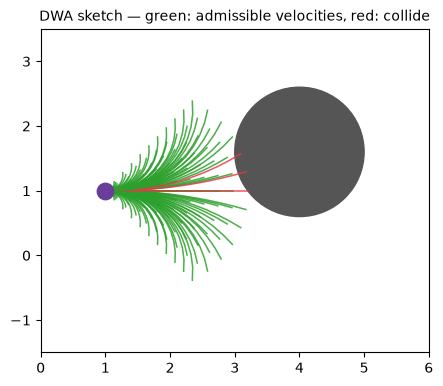

A real DWA also scores the admissible arcs (progress toward goal, clearance, speed) and respects acceleration limits; MPC replaces the sampling with an optimization over a horizon. Both produce VELOCITIES, not routes — they are local planners, not replacements for a global A*/D* Lite.


In [35]:
# DWA in one picture: sample (v, omega), roll each forward briefly, keep safe ones.
def dwa_sketch(ax):
    robot = np.array([1.0, 1.0, 0.0])              # x, y, theta
    obstacles = [np.array([4.0, 1.6, 1.0])]         # x, y, radius
    dt, horizon = 0.1, 1.2
    for v in np.linspace(0.2, 2.0, 10):
        for w in np.linspace(-1.6, 1.6, 13):
            pose, traj, collides = robot.copy(), [], False
            for _ in range(int(horizon / dt)):
                pose = pose + np.array([v * math.cos(pose[2]) * dt,
                                        v * math.sin(pose[2]) * dt, w * dt])
                traj.append(pose[:2].copy())
                if any(np.linalg.norm(pose[:2] - ob[:2]) < ob[2] for ob in obstacles):
                    collides = True
                    break
            t = np.array(traj)
            ax.plot(t[:, 0], t[:, 1], color="#e63946" if collides else "#2ca02c",
                    lw=1.1, alpha=0.85)
    for ob in obstacles:
        ax.add_patch(plt.Circle(ob[:2], ob[2], color="#555555"))
    ax.scatter(*robot[:2], c=PALETTE["robot"], s=140, zorder=6)
    ax.set_xlim(0, 6); ax.set_ylim(-1.5, 3.5); ax.set_aspect("equal")
    ax.set_title("DWA sketch — green: admissible velocities, red: collide", fontsize=10)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
dwa_sketch(ax)
plt.show()
print("A real DWA also scores the admissible arcs (progress toward goal, clearance,"
      " speed) and respects acceleration limits; MPC replaces the sampling with an"
      " optimization over a horizon. Both produce VELOCITIES, not routes — they are"
      " local planners, not replacements for a global A*/D* Lite.")

## 26. Global vs Local — Putting It Together

```text
GLOBAL PLANNER        "route through the known world"
      ↓
GLOBAL PATH
      ↓
LOCAL PLANNER         "follow the route around what I see now"
      ↓
ROBOT MOTION
```

A useful mental model: the global planner is strategy, the local planner is
tactics, control is muscle. When the world matches the map, the global path
is followed almost verbatim; when it doesn't, the local planner smooths over
small surprises and *big* surprises trigger a global replan — which is
exactly the loop the robot simulation in Section 20 demonstrated.

## 27. Complete Autonomous Navigation Architecture

The full loop this lab has been building toward:

```text
                  SENSOR DATA
                      │
                      ▼
              ┌───────────────┐
              │   MAP / COST  │
              │      MAP      │
              └───────┬───────┘
                      │
                      ▼
             GLOBAL PATH PLANNER
                      │
            ┌─────────┴─────────┐
            │                   │
           A*                D* Lite
            │                   │
            └─────────┬─────────┘
                      ▼
                 GLOBAL PATH
                      ▼
                LOCAL PLANNER
                 DWA / MPC
                      ▼
                MOTION CONTROL
                      ▼
                    ROBOT
                      ▼
                  SENSORS
                      │
                      └──────────→ MAP UPDATE   (the feedback loop)
```

The feedback loop is the point: sensing updates the map, the map shapes
planning, planning commands motion, motion produces new sensor data.

## 28. Algorithm Comparison

No algorithm is "best" — each is a tool for a situation:

| Algorithm | Main purpose | Weighted? | Heuristic? | Replanning? | Grid-specific? | Continuous? | Typical robotics role |
|---|---|---|---|---|---|---|---|
| BFS | fewest-edges path | no | no | no | no | no | reachability checks, unweighted grids |
| DFS | any path / traversal | no | no | no | no | no | exhaustive exploration, cycle detection |
| Dijkstra | cheapest path | yes | no | from scratch | no | no | small maps, dense graphs, baselines |
| Greedy Best-First | fast reasonable path | no | yes | no | no | no | rough routes when optimality doesn't matter |
| A* | cheapest path, directed | yes | yes | from scratch | no | no | the workhorse global planner |
| Bidirectional Dijkstra | cheaper frontier via 2 searches | yes | no | no | no | no | long corridors, single-pair queries |
| Bidirectional A* | both tricks combined | yes | yes | no | no | no | point-to-point on big known maps |
| JPS | uniform-grid A*, fewer expansions | uniform only | octile | no | yes (8-dir) | no | game-style uniform cost grids |
| Theta* | any-angle paths | uniform only | yes | no | yes | partially | smooth routes on sparse grids |
| D* Lite | repair after world changes | yes | yes | **incremental** | no | no | robots that sense while moving |
| RRT | feasible continuous path | no (geometry) | no | resample | no | **yes** | high-dof / continuous motion planning |
| RRT* | converging to optimal | no (geometry) | no | resample | no | **yes** | offline-quality continuous paths |
| PRM | reusable free-space roadmap | no (geometry) | no | rebuild | no | **yes** | many queries, static world |
| DWA | reactive velocity choice | no | no | continuous | no | **yes** | local planner around dynamic obstacles |
| MPC | optimized control sequences | via costs | no | every cycle | no | **yes** | local planning + dynamics constraints |

Relationships demonstrated live earlier in this notebook:

```text
Greedy:  f(n) = h(n)        Dijkstra:  f(n) = g(n)        A*:  f(n) = g(n) + h(n)

A* with h(n) = 0  =  Dijkstra
```

Algorithms may expand very different numbers of nodes while producing the
same optimal path — expansion count is where heuristics pay off.

## 29. Experiments / Exercises

Things to try in the explorer (Section 15) and benchmarks (Section 21):

1. **Heuristic strength**: on the Weighted Terrain preset, run A* with
   `manhattan`, then `cost-aware`. Which matches Dijkstra's cost? Which
   expands fewer nodes? Why?
2. **Greedy traps**: build a maze, drop obstacles until Greedy returns a
   clearly suboptimal path (compare with Dijkstra in the Compare table).
3. **Corridor maps**: on long empty maps, compare expansions of Dijkstra vs
   bidirectional Dijkstra. When does the bidirectional advantage shrink?
4. **JPS territory**: generate Random Obstacle maps (uniform cost) and watch
   the JPS vs A* expansion gap grow with grid size.
5. **D\* Lite stress**: in the robot simulation, drop obstacles repeatedly.
   When does D* Lite repair stop being cheaper than a fresh A*?
6. **Unreachable goals**: seal the goal into a corner with obstacles and
   confirm every algorithm reports `no path` instead of hanging.
7. **Overestimating on purpose**: invent `h(n) = 4 × octile` and observe
   fewer expansions but worse paths (weighted A* behaviour).

## 30. Validation and Tests

The lab's own regression suite, run fresh every execution:

- maps: 4×4 to 50×50 across all presets (empty / sparse / dense / maze /
  weighted terrain),
- every returned path is *valid* (consecutive neighbors, passable cells,
  reported cost matches the map's arithmetic),
- A* with an admissible heuristic agrees with Dijkstra's optimal cost on
  every map,
- BFS finds fewest-edge paths; Dijkstra finds cheapest,
- sealed-off goals produce `no path` everywhere, no crashes,
- cross-check against NetworkX's independent Dijkstra on smaller maps.

NetworkX is used **only** here, as an independent reference — never as the
teaching implementation.

In [36]:
# --- the lab's own regression suite --------------------------------------------
# (NetworkX appears ONLY here, as an independent judge of our hand-written code.)

def _prepare(preset, size, seed):
    grid = PRESETS[preset](size, size, seed=seed, eight=False)
    start, goal = (0, 0), (grid.rows - 1, grid.cols - 1)
    # mazes wall off the border: open the corner cells and one gate each so the
    # start/goal actually connect to the maze interior
    for cell in (start, goal, (start[0], start[1] + 1), (goal[0], goal[1] - 1)):
        grid.unblock(cell)
    return grid, start, goal

def run_test_suite():
    results = []

    def check(label, cond):
        results.append((label, bool(cond)))

    for size in (4, 10, 25, 50):
        for preset in PRESETS:
            grid, start, goal = _prepare(preset, size, seed=42 + size)
            reachable = _reachable(grid, start, goal)

            dij = dijkstra(grid, start, goal)
            ast = a_star(grid, start, goal, h_cost_aware)
            bf = bfs(grid, start, goal)
            gr = greedy_best_first(grid, start, goal)

            check(f"{size} {preset}: status matches reachability",
                  (dij.status == "goal") == reachable and (ast.status == "goal") == reachable)
            if reachable:
                check(f"{size} {preset}: dijkstra path valid",
                      validate_path(grid, dij.path, start, goal)[0])
                check(f"{size} {preset}: A* cost == dijkstra cost",
                      math.isclose(dij.path_cost, ast.path_cost, rel_tol=1e-9))
                check(f"{size} {preset}: A* path valid",
                      validate_path(grid, ast.path, start, goal)[0])
                check(f"{size} {preset}: BFS fewest edges",
                      len(bf.path) <= len(dij.path))
                check(f"{size} {preset}: greedy path valid",
                      validate_path(grid, gr.path, start, goal)[0])
                man = a_star(grid, start, goal, h_manhattan)
                check(f"{size} {preset}: inadmissible h never 'better' than optimal",
                      man.path_cost >= dij.path_cost - 1e-9)
                if size <= 50:
                    G = nx.Graph()
                    for r in range(grid.rows):
                        for c in range(grid.cols):
                            if grid.passable((r, c)):
                                for nb in grid.neighbors((r, c)):
                                    G.add_edge((r, c), nb, weight=grid.move_cost((r, c), nb))
                    if goal in G and start in G and nx.has_path(G, start, goal):
                        check(f"{size} {preset}: matches networkx dijkstra",
                              math.isclose(nx.dijkstra_path_length(G, start, goal),
                                           dij.path_cost, rel_tol=1e-9))

    # sealed goal -> no path, everywhere
    m = create_empty_grid(12, 12)
    for r in range(12):
        m.block((r, 6))
    for algo in (bfs, dfs, dijkstra, greedy_best_first, a_star):
        res = algo(m, (6, 2), (6, 9))
        check(f"sealed map {algo.__name__} reports no path",
              res.status == "no path" and res.path is None)

    # D* Lite repair keeps optimality
    dm, ds, dg = make_dstar_test_map()
    dsl = DStarLite(dm, ds, dg)
    walk = dsl.path_ahead()
    for cell in walk[:6]:
        dsl.move_to(cell)
    blocked = walk[8]
    dsl.discover_change(blocked, now_blocked=True)
    fresh = a_star(dm, dsl.robot, dg)
    check("D* Lite repaired cost == fresh A* cost",
          dsl.status == "goal" and math.isclose(dsl.g[dsl.robot], fresh.path_cost, rel_tol=1e-9))

    # JPS == A* on uniform 8-connected maps
    for seed in (3, 8):
        jm = create_random_obstacles(31, 31, 0.25, seed=seed, eight=True)
        jst = jump_point_search(jm, (0, 0), (30, 30))
        jref = a_star(jm, (0, 0), (30, 30), h_octile)
        check(f"JPS cost == A* cost (seed {seed})",
              math.isclose(jst.path_cost, jref.path_cost, rel_tol=1e-9))

    ok = sum(1 for _, c in results if c)
    print(f"{ok}/{len(results)} checks passed")
    for label, c in results:
        if not c:
            print("  FAIL:", label)
    return ok == len(results)

def make_dstar_test_map():
    m = create_empty_grid(17, 25)
    for r in range(17):
        if r not in (3, 4, 5) and r not in (11, 12, 13):
            m.block((r, 12))
    return m, (8, 1), (8, 23)

assert run_test_suite(), "test suite failed"
print("\nAll validation checks passed: paths valid, costs optimal where guaranteed,"
      " no-path cases handled, D* Lite and JPS verified against fresh A*.")

168/168 checks passed

All validation checks passed: paths valid, costs optimal where guaranteed, no-path cases handled, D* Lite and JPS verified against fresh A*.


## 31. Final Summary

You started with a 4×4 graph and finished with a navigation laboratory:

- **Maps**: configurable grids, obstacles, weighted terrain, mazes, seeds.
- **Uninformed search**: BFS (fewest edges), DFS (traversal), Dijkstra
  (cheapest, `f = g`).
- **Heuristic search**: Greedy (`f = h`), A* (`f = g + h`), four heuristics
  and the admissibility story — grid geometry ≠ traversal cost.
- **Smarter search**: bidirectional Dijkstra/A*, JPS for uniform grids,
  Theta* for any-angle paths.
- **Robots that cope with change**: dynamic obstacles, incremental
  replanning with D* Lite, a sensing robot with a known/true map split.
- **Continuous space**: RRT, RRT*, PRM sketches; DWA/MPC conceptually.
- **Engineering habits**: algorithms separated from visualization, one state
  model, measured (not asserted) performance, NetworkX as an independent
  judge.

The next steps beyond this notebook: real sensor noise, localization
(SLAM), kinodynamic planners, and actual control loops. The planning
intuition you built here is the part that carries over.